# Marketing Campaign Response — Data Understanding and EDA

Business framing and exploratory analysis of customer demographics, purchase behaviour, campaign history and response. This notebook provides the evidence behind the later classification decisions.

> **Portfolio note:** This notebook is a curated version of completed MSc coursework. The analytical code and saved outputs come from the original work; presentation, headings, file paths and explanatory text have been cleaned for portfolio use. The dataset itself is not redistributed here.


**CONSTANTS**


In [2]:
FILE_NAME = 'data/campaign.xlsx'


**IMPORTS**


In [4]:
import pandas as pd
from IPython.display import display, HTML
import holoviews as hv
import seaborn as sns
import hvplot.pandas
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.ensemble import ExtraTreesClassifier
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold
import shap


**OPTIONS**


In [7]:
def categorical_histogram(df, column, height=2000, width=5000, xrotation=45):
    histogram = df[column].value_counts().hvplot.bar(
        height=height,
        width=width,
        color='#E3120B',
        title=f'Histogram // Column: {column}',
        xlabel='',
        ylabel='',
    )

    return histogram.opts(
        fontsize={'title': 16, 'labels': 10, 'xticks': 15, 'yticks': 15},
        xrotation=xrotation,
        bgcolor='white',
        xaxis='bottom',
        yaxis='left',
    )


def line_chart(df, column, height=1200, width=1000):
    histogram = df[column].value_counts().hvplot.line(
        height=height,
        width=width,
        color='#E3120B',
        title=f'Histogram // Column: {column}',
        xlabel='',
        ylabel='',
    )

    return histogram.opts(
        fontsize={'title': 16, 'labels': 10, 'xticks': 15, 'yticks': 15},
        xrotation=45,
        bgcolor='white',
        xaxis='bottom',
        yaxis='left',
    )


def numerical_histogram(df, column, height=800, width=1200, bins=100):
    histogram = df[column].hvplot.hist(
        bins=bins,
        height=height,
        width=width,
        color='#E3120B',
        title=f'Histogram // Column: {column}',
        xlabel=column,
        ylabel='Frequency',
        tools=['hover']
    )

    return histogram.opts(
        fontsize={'title': 20, 'labels': 14, 'xticks': 12, 'yticks': 12},
        xrotation=45,
        bgcolor='white',
        xaxis='bottom',
        yaxis='left'
    )


def numerical_boxplot(df, column, height=600, width=800):
    # Convert height and width from "pixels" to "inches" (roughly)
    fig, ax = plt.subplots(figsize=(width / 100, height / 100))

    ax.boxplot(
        df[column],
        patch_artist=True,             # Enables facecolor on the boxes
        boxprops=dict(facecolor='#1f77b4')
    )

    ax.set_title(f'Box Plot // Column: {column}')
    ax.set_ylabel(column)

    plt.show()

def spectral_plot(df_input, column_discriminatory, column_data, height=800, width=800):
    # Create the data
    df = df_input[[column_data, column_discriminatory]]
    
    # Initialize the FacetGrid object
    pal = sns.cubehelix_palette(10, rot=-.25, light=.7)
    g = sns.FacetGrid(df, row=column_discriminatory, hue=column_discriminatory, aspect=15, height=.5, palette=pal)
    
    # Draw the densities in a few steps
    g.map(sns.kdeplot, column_data,
          bw_adjust=.5, clip_on=False,
          fill=True, alpha=1, linewidth=1.5)
    g.map(sns.kdeplot, column_data, clip_on=False, color="w", lw=2, bw_adjust=.5)
    
    # passing color=None to refline() uses the hue mapping
    g.refline(y=0, linewidth=2, linestyle="-", color=None, clip_on=False)
    
    
    # Define and use a simple function to label the plot in axes coordinates
    def label(x, color, label):
        ax = plt.gca()
        ax.text(0, .2, label, fontweight="bold", color=color,
                ha="left", va="center", transform=ax.transAxes)
    
    
    g.map(label, column_data)
    
    # Set the subplots to overlap
    g.figure.subplots_adjust(hspace=-.25)
    
    # Remove axes details that don't play well with overlap
    g.set_titles("")
    g.set(yticks=[], ylabel="")
    g.despine(bottom=True, left=True)


# Business Understanding


The goal of this model is to predict which customers will respond positively to marketing campaigns, in a way that increases the budgetary and effort efficacy of the marketing strategy. The goal is to predict the responses in a way that can increase response or reduce expenses (hopefully both).  
Response is defined by how the customer reacted to the last campaign. This is the target of the model.


# 0. Data Understanding


## 0.1 Data Loading and Initial Inspection


In [12]:
df_camp = pd.read_excel('./data/campaign.xlsx')


#### Dataset description

- **AcceptedCmp1** - 1 if customer accepted the offer in the 1st campaign, 0 otherwise 
- **AcceptedCmp2** - 1 if customer accepted the offer in the 2nd campaign, 0 otherwise 
- **AcceptedCmp3** - 1 if customer accepted the offer in the 3rd campaign, 0 otherwise 
- **AcceptedCmp4** - 1 if customer accepted the offer in the 4th campaign, 0 otherwise 
- **AcceptedCmp5** - 1 if customer accepted the offer in the 5th campaign, 0 otherwise 
- **Response (target)** - 1 if customer accepted the offer in the last campaign, 0 otherwise 
- **Complain** - 1 if customer complained in the last 2 years
- **DtCustomer** - date of customer’s enrolment with the company
- **Education** - customer’s level of education
- **Marital** - customer’s marital status
- **Kidhome** - number of small children in customer’s household
- **Teenhome** - number of teenagers in customer’s household
- **Income** - customer’s yearly household income
- **MntFishProducts** - amount spent on fish products in the last 2 years
- **MntMeatProducts** - amount spent on meat products in the last 2 years
- **MntFruits** - amount spent on fruits products in the last 2 years
- **MntSweetProducts** - amount spent on sweet products in the last 2 years
- **MntWines** - amount spent on wine products in the last 2 years
- **MntGoldProds** - amount spent on gold products in the last 2 years
- **NumDealsPurchases** - number of purchases made with discount
- **NumCatalogPurchases** - number of purchases made using catalogue
- **NumStorePurchases** - number of purchases made directly in stores
- **NumWebPurchases** - number of purchases made through company’s web site
- **NumWebVisitsMonth** - number of visits to company’s web site in the last month
- **Recency** - number of days since the last purchase


In [14]:
df_camp.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635.0,88.0,546,172,88,88.0,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11.0,1.0,6,2,1,6.0,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426.0,49.0,127,111,21,42.0,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11.0,4.0,20,10,3,5.0,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173.0,43.0,118,46,27,15.0,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [15]:
df_camp.info()

df_camp.describe(include='all')


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2237 non-null   float64
 10  MntFruits            2238 non-null   float64
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2187 non-null   float64
 15  NumDealsPurchases    2240 non-null   i

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2240,2240,2216.000000,2240.000000,2240.000000,2240,2240.000000,2237.000000,2238.000000,2240.000000,2240.000000,2.240000e+03,2187.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
unique,NaN,NaN,5,8,NaN,NaN,NaN,665,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Graduation,Married,NaN,NaN,NaN,2012-08-31,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,1127,864,NaN,NaN,NaN,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5592.159821,1968.805804,NaN,NaN,52247.251354,0.444196,0.506250,NaN,49.109375,303.838623,26.252011,166.950000,37.523661,1.163415e+04,44.596251,2.325000,4.084821,2.662054,5.790179,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,NaN,NaN,25173.076661,0.538398,0.544538,NaN,28.962453,336.576209,39.699755,225.715373,54.630198,4.973786e+05,52.419487,1.932238,2.778714,2.923101,3.250958,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,NaN,NaN,1730.000000,0.000000,0.000000,NaN,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,NaN,NaN,35303.000000,0.000000,0.000000,NaN,24.000000,24.000000,1.000000,16.000000,3.000000,1.000000e+00,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,NaN,NaN,51381.500000,0.000000,0.000000,NaN,49.000000,173.000000,8.000000,67.000000,12.000000,8.000000e+00,25.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,NaN,NaN,68522.000000,1.000000,1.000000,NaN,74.000000,504.000000,33.000000,232.000000,50.000000,3.325000e+01,57.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000


In [16]:
df_camp.isnull().sum()


ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                3
MntFruits               2
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds           53
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [17]:
df_camp = df_camp.drop_duplicates().dropna()


In [18]:
# change variable type in the cases it is wrong
df_camp = df_camp.astype({'AcceptedCmp3': bool, 
                          'AcceptedCmp4': bool, 
                          'AcceptedCmp5': bool, 
                          'AcceptedCmp1': bool, 
                          'AcceptedCmp2': bool, 
                          'Response': bool, 
                          'Complain': bool})
df_camp = df_camp.astype({'ID': object, 
                          'Year_Birth': object, 
                          'Kidhome': object, 
                          'Teenhome': object})
df_camp = df_camp.astype({'Income': int})
df_camp['Dt_Customer'] = pd.to_datetime(df_camp['Dt_Customer'])


In [19]:
df_camp.info()


<class 'pandas.core.frame.DataFrame'>
Index: 2158 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2158 non-null   object        
 1   Year_Birth           2158 non-null   object        
 2   Education            2158 non-null   object        
 3   Marital_Status       2158 non-null   object        
 4   Income               2158 non-null   int64         
 5   Kidhome              2158 non-null   object        
 6   Teenhome             2158 non-null   object        
 7   Dt_Customer          2158 non-null   datetime64[ns]
 8   Recency              2158 non-null   int64         
 9   MntWines             2158 non-null   float64       
 10  MntFruits            2158 non-null   float64       
 11  MntMeatProducts      2158 non-null   int64         
 12  MntFishProducts      2158 non-null   int64         
 13  MntSweetProducts     2158 non-null   i

In [20]:
df_camp.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138,0,0,2012-09-04,58,635.0,88.0,546,172,88,88.0,3,8,10,4,7,False,False,False,False,False,False,3,11,True
1,2174,1954,Graduation,Single,46344,1,1,2014-03-08,38,11.0,1.0,6,2,1,6.0,2,1,1,2,5,False,False,False,False,False,False,3,11,False
2,4141,1965,Graduation,Together,71613,0,0,2013-08-21,26,426.0,49.0,127,111,21,42.0,1,8,2,10,4,False,False,False,False,False,False,3,11,False
3,6182,1984,Graduation,Together,26646,1,0,2014-02-10,26,11.0,4.0,20,10,3,5.0,2,2,0,4,6,False,False,False,False,False,False,3,11,False
4,5324,1981,PhD,Married,58293,1,0,2014-01-19,94,173.0,43.0,118,46,27,15.0,5,5,3,6,5,False,False,False,False,False,False,3,11,False


In [21]:
df_camp.describe(include='all')


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2158.0,2158.0,2158,2158,2158.000000,2158.0,2158.0,2158,2158.000000,2158.000000,2158.000000,2158.000000,2158.000000,2.158000e+03,2158.000000,2158.000000,2158.000000,2158.000000,2158.000000,2158.000000,2158,2158,2158,2158,2158,2158,2158.0,2158.0,2158
unique,2158.0,59.0,5,8,NaN,3.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,2,2,2,2,2,NaN,NaN,2
top,5524.0,1976.0,Graduation,Married,NaN,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,False,False,False,False,False,NaN,NaN,False
freq,1.0,87.0,1088,836,NaN,1255.0,1122.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1996,1998,2000,2019,2128,2138,NaN,NaN,1832
mean,NaN,NaN,NaN,NaN,52417.677943,NaN,NaN,2013-07-20 16:26:54.828545024,48.977757,308.079703,26.756719,169.139481,38.058851,1.207553e+04,44.456441,2.322521,4.113994,2.701576,5.837813,5.298888,NaN,NaN,NaN,NaN,NaN,NaN,3.0,11.0,NaN
min,NaN,NaN,NaN,NaN,1730.000000,NaN,NaN,2012-07-30 00:00:00,0.000000,0.000000,0.000000,0.000000,-1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,3.0,11.0,NaN
25%,NaN,NaN,NaN,NaN,35461.500000,NaN,NaN,2013-01-17 00:00:00,24.000000,24.000000,2.000000,16.000000,3.000000,1.000000e+00,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,NaN,NaN,NaN,NaN,NaN,NaN,3.0,11.0,NaN
50%,NaN,NaN,NaN,NaN,51684.000000,NaN,NaN,2013-07-08 12:00:00,49.000000,180.000000,8.000000,68.000000,12.000000,8.500000e+00,25.000000,2.000000,4.000000,2.000000,5.000000,6.000000,NaN,NaN,NaN,NaN,NaN,NaN,3.0,11.0,NaN
75%,NaN,NaN,NaN,NaN,68682.000000,NaN,NaN,2013-12-31 18:00:00,74.000000,508.750000,33.750000,237.750000,50.000000,3.400000e+01,57.000000,3.000000,6.000000,4.000000,8.000000,7.000000,NaN,NaN,NaN,NaN,NaN,NaN,3.0,11.0,NaN
max,NaN,NaN,NaN,NaN,666666.000000,NaN,NaN,2042-11-09 00:00:00,99.000000,1493.000000,199.000000,1725.000000,259.000000,2.342344e+07,321.000000,15.000000,27.000000,28.000000,13.000000,20.000000,NaN,NaN,NaN,NaN,NaN,NaN,3.0,11.0,NaN


## 0.2 EDA: Univariate Analysis


`Year_Birth` | category


:Bars   [Year_Birth]   (count)
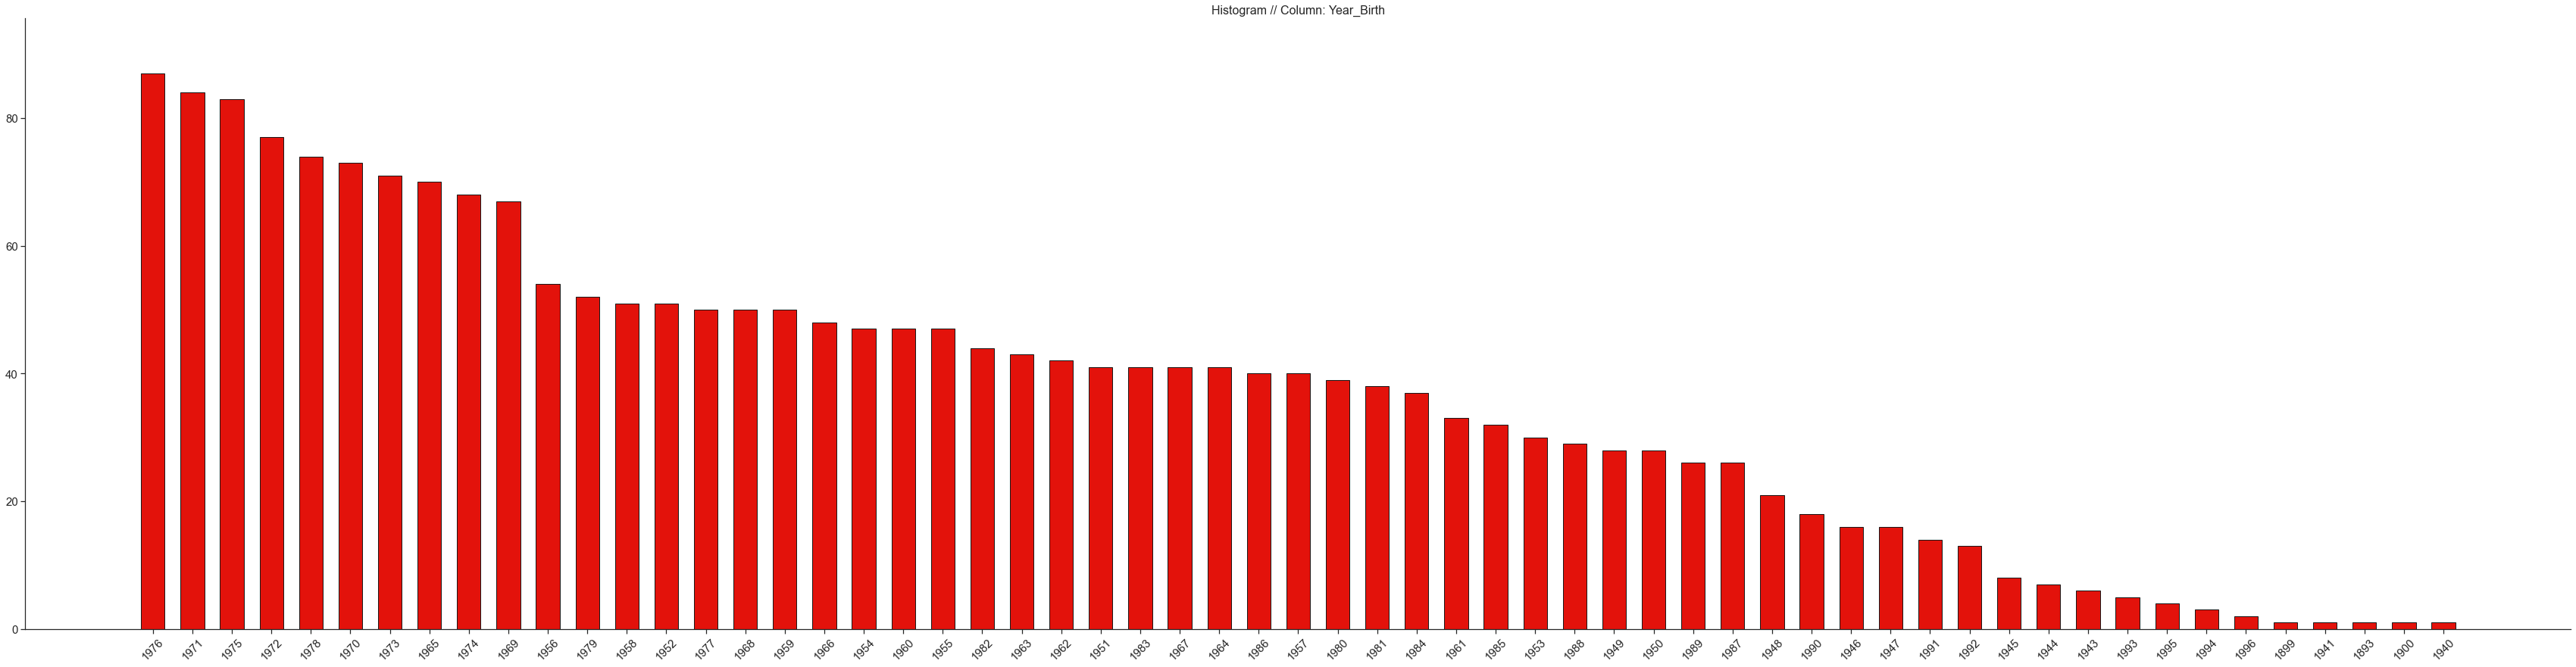

In [24]:
categorical_histogram(df_camp, 'Year_Birth', height=1200)


:Histogram   [Year_Birth]   (Year_Birth_count)
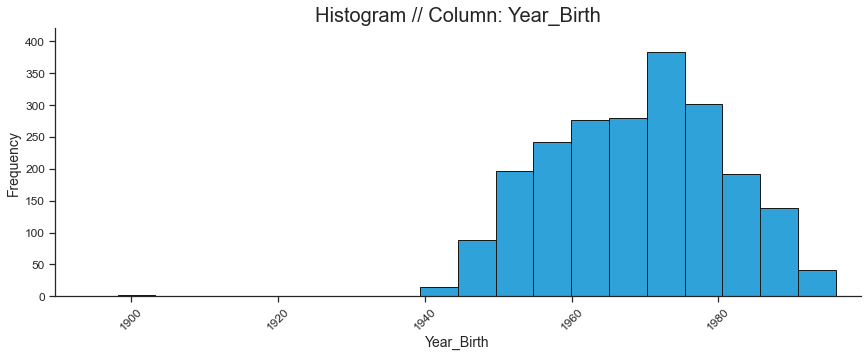

In [25]:
numerical_histogram(df_camp, 'Year_Birth', bins=20, height=400)


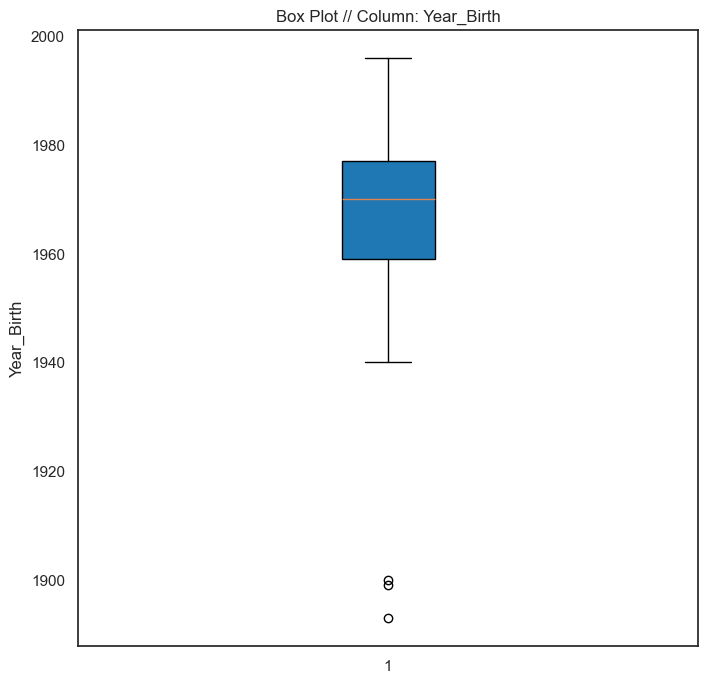

In [26]:
numerical_boxplot(df_camp, 'Year_Birth', height=800, width=800)


`Education`|


`Marital_Status` | Category


:Bars   [Marital_Status]   (count)
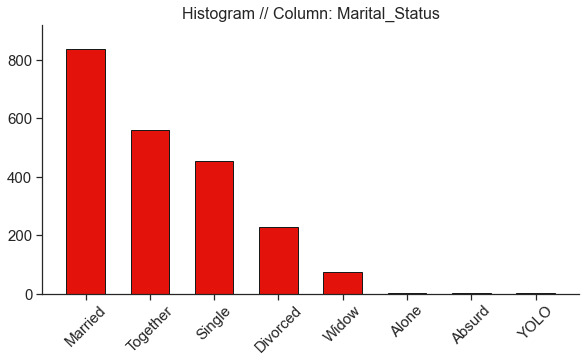

In [29]:
categorical_histogram(df_camp, 'Marital_Status', height=400, width=800)


In [30]:
df_camp['Marital_Status'].value_counts()


Marital_Status
Married     836
Together    560
Single      454
Divorced    228
Widow        73
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

`Alone` can be `Single`, but we might have to delete the other 2 --> outliers


In [32]:
# 1) drop the rows
mask_keep = ~df_camp['Marital_Status'].isin(['YOLO','Absurd'])
df_camp = df_camp.loc[mask_keep]

# 2) remap Alone→Single in place
df_camp.loc[df_camp['Marital_Status']=='Alone', 'Marital_Status'] = 'Single'

df_camp['Marital_Status'].value_counts()


Marital_Status
Married     836
Together    560
Single      457
Divorced    228
Widow        73
Name: count, dtype: int64

`Income` | Numerical


:Histogram   [Income]   (Income_count)
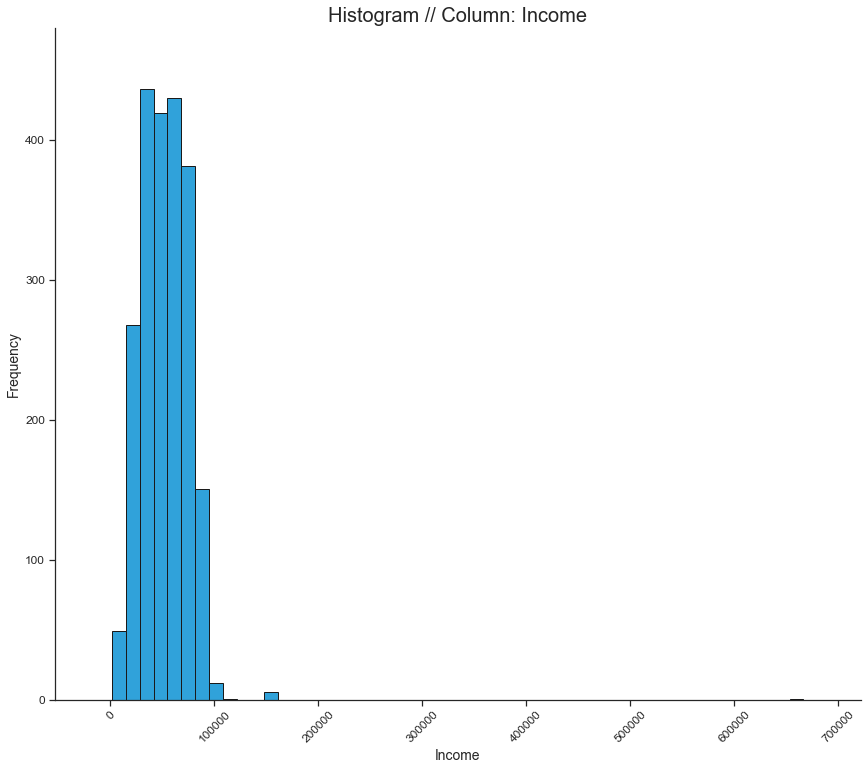

In [34]:
numerical_histogram(df_camp, 'Income', bins=50, height=1000)


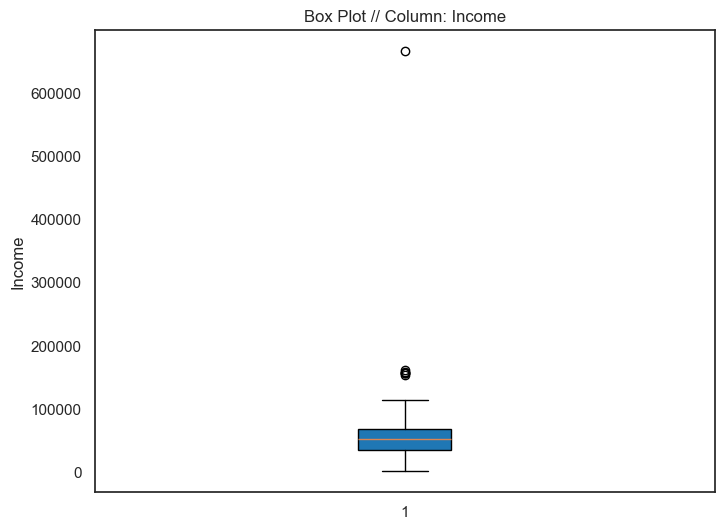

In [35]:
numerical_boxplot(df_camp, 'Income')


The income is mostly under 100K. There are outliers are around 150K and 650K.


In [37]:
q1 = df_camp['Income'].quantile(0.25)
q3 = df_camp['Income'].quantile(0.75)
iqr = q3 - q1

upper_bound = q3 + 1.5 * iqr

top_non_outlier = df_camp.loc[df_camp['Income'] <= upper_bound, 'Income'].max()
print("Top non-outlier (top of the boxplot) Income value:", top_non_outlier)


Top non-outlier (top of the boxplot) Income value: 113734


In [38]:
outlier_mask = df_camp['Income'] > 120000

# Count the number of outliers
n_outliers = outlier_mask.sum()
print("Number of outlier rows (Income > 120K):", n_outliers)


Number of outlier rows (Income > 120K): 7


`Kidhome` | Category


:Bars   [Kidhome]   (count)
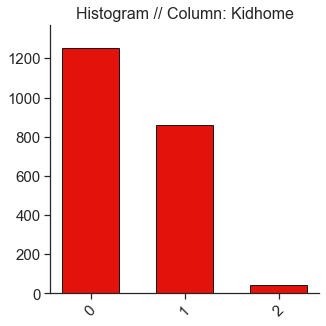

In [40]:
categorical_histogram(df_camp, 'Kidhome', height=400, width=400)


In [41]:
df_camp['Kidhome'].value_counts()


Kidhome
0    1251
1     860
2      43
Name: count, dtype: int64

`Teenhome` | Category


:Bars   [Teenhome]   (count)
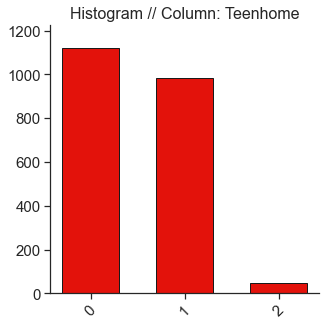

In [43]:
categorical_histogram(df_camp, 'Teenhome', height=400, width=400)


In [44]:
df_camp['Teenhome'].value_counts()


Teenhome
0    1120
1     985
2      49
Name: count, dtype: int64

Very similar distribution to `Kidhome`.


`Dt_Customer` | Datetime


:Bars   [Customer_Month]   (0)
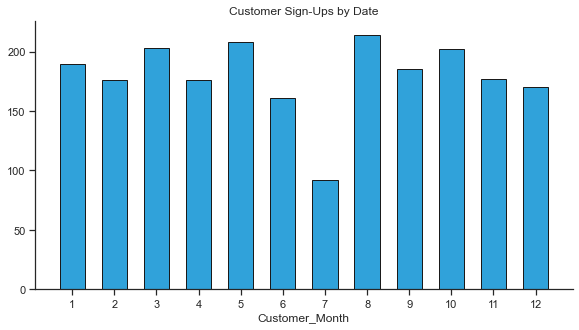

In [47]:
# Extract the month from your date column
df_camp['Customer_Month'] = df_camp['Dt_Customer'].dt.month

# Aggregate counts by date, assuming 'Dt_Customer' holds the date
daily_counts = df_camp.groupby('Customer_Month').size()
daily_counts.hvplot.bar(title='Customer Sign-Ups by Date', width=800, height=400)


# Box plot of Income for each month
#df_camp.hvplot.box(y='Income', by='Customer_Month', title='Monthly Income Distribution', height=800, width=800)


:Bars   [Customer_Year]   (0)
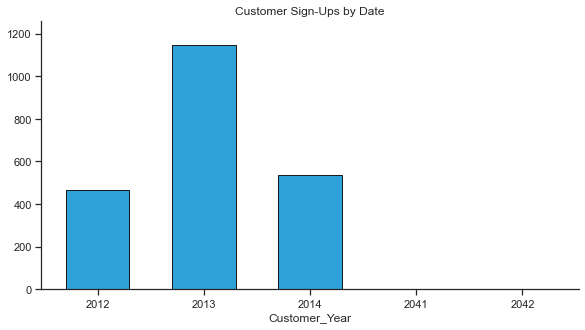

In [48]:
# Extract the month from your date column
df_camp['Customer_Year'] = df_camp['Dt_Customer'].dt.year

# Aggregate counts by date, assuming 'Dt_Customer' holds the date
daily_counts = df_camp.groupby('Customer_Year').size()
daily_counts.hvplot.bar(title='Customer Sign-Ups by Date', width=800, height=400)


# Box plot of Income for each month
#df_camp.hvplot.box(y='Income', by='Customer_Month', title='Monthly Income Distribution', height=800, width=800)


`Recency` | Numerical


:Histogram   [Recency]   (Recency_count)
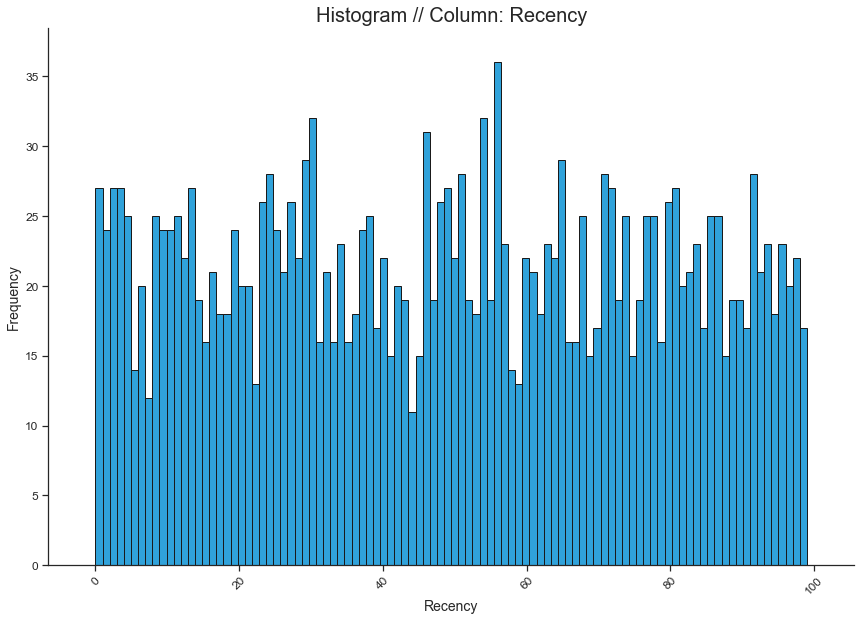

In [51]:
numerical_histogram(df_camp, 'Recency', bins=100, height=800)


`MntWines` | Numerical


:Histogram   [MntWines]   (MntWines_count)
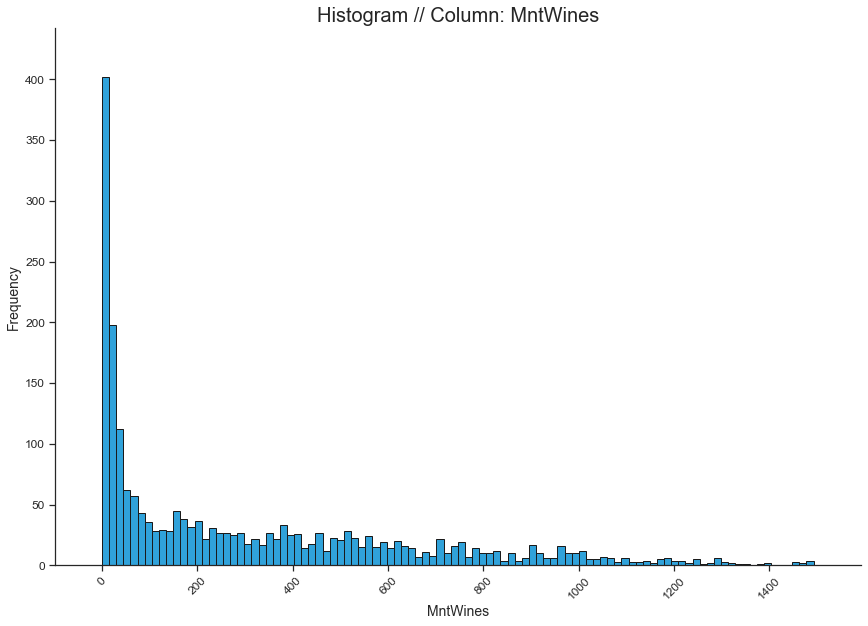

In [53]:
numerical_histogram(df_camp, 'MntWines', bins=100, height=800)


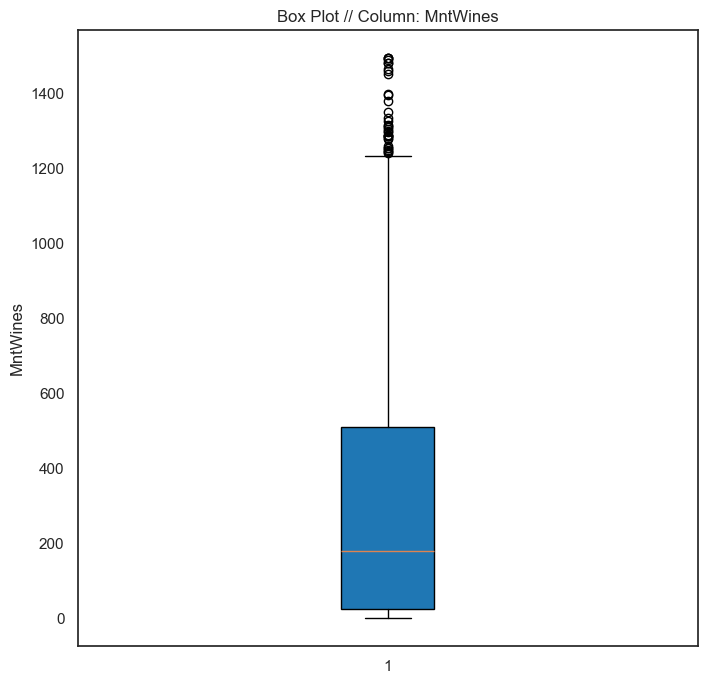

In [54]:
numerical_boxplot(df_camp, 'MntWines', height=800, width=800)


`MntFruits`| Numerical


:Histogram   [MntFruits]   (MntFruits_count)
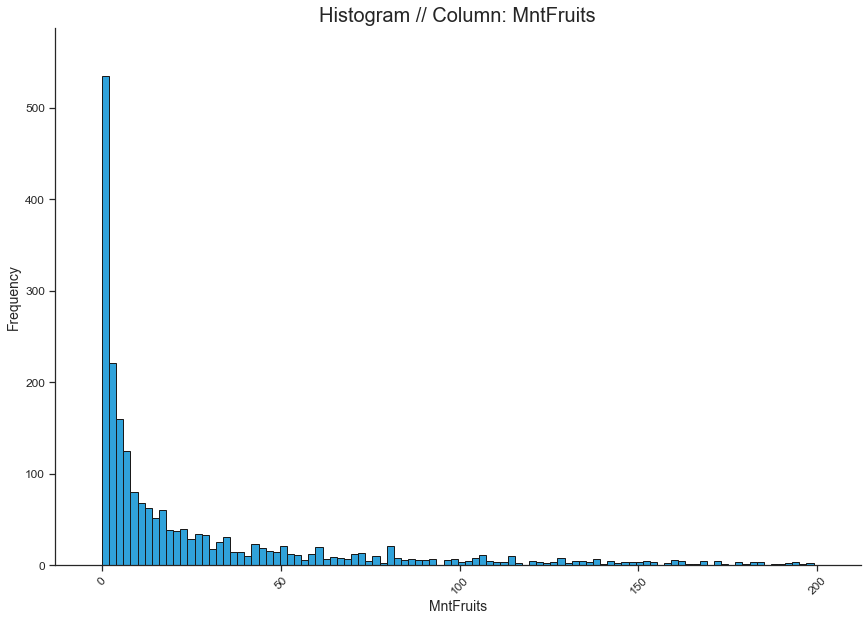

In [56]:
numerical_histogram(df_camp, 'MntFruits', bins=100, height=800)


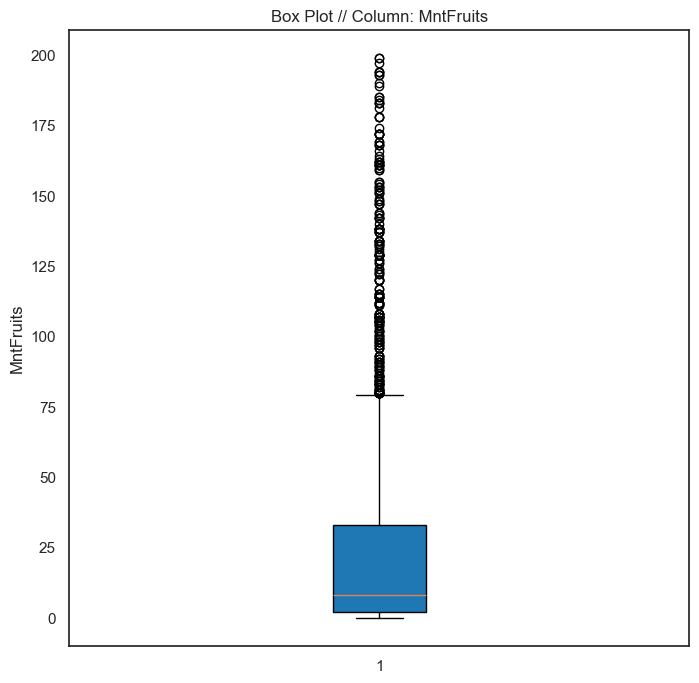

In [57]:
numerical_boxplot(df_camp, 'MntFruits', height=800, width=800)


`MntMeatProducts` | Numerical


:Histogram   [MntMeatProducts]   (MntMeatProducts_count)
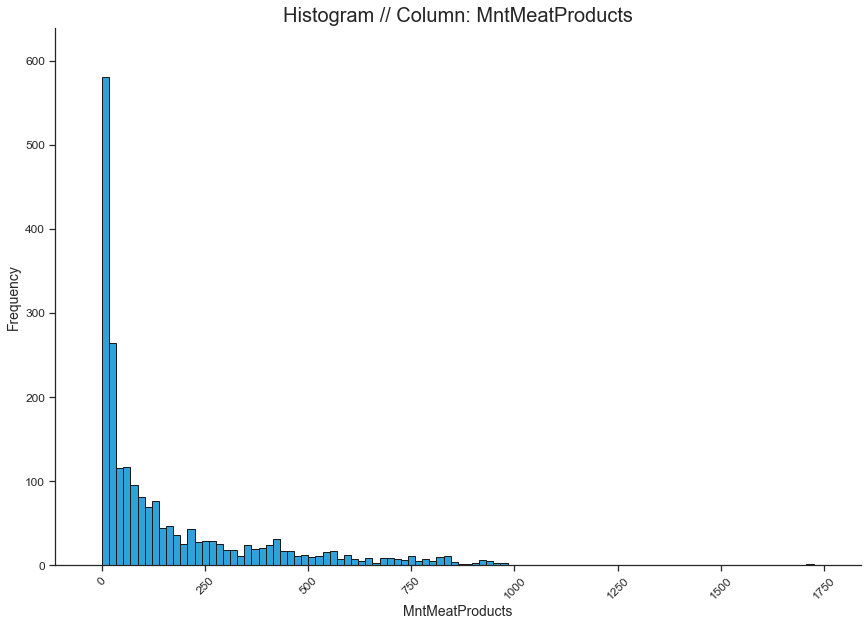

In [59]:
numerical_histogram(df_camp, 'MntMeatProducts', bins=100, height=800)


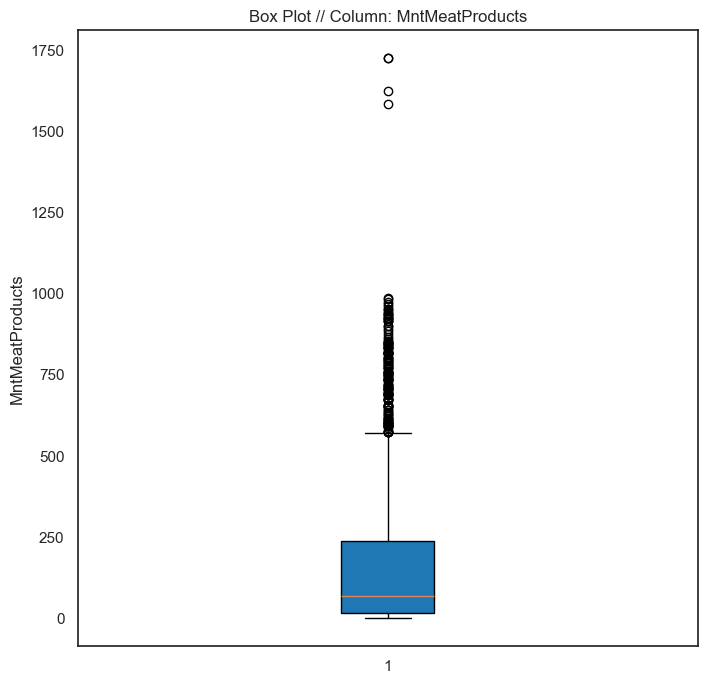

In [60]:
numerical_boxplot(df_camp, 'MntMeatProducts', height=800, width=800)


`MntFishProducts`| Numerical


:Histogram   [MntFishProducts]   (MntFishProducts_count)
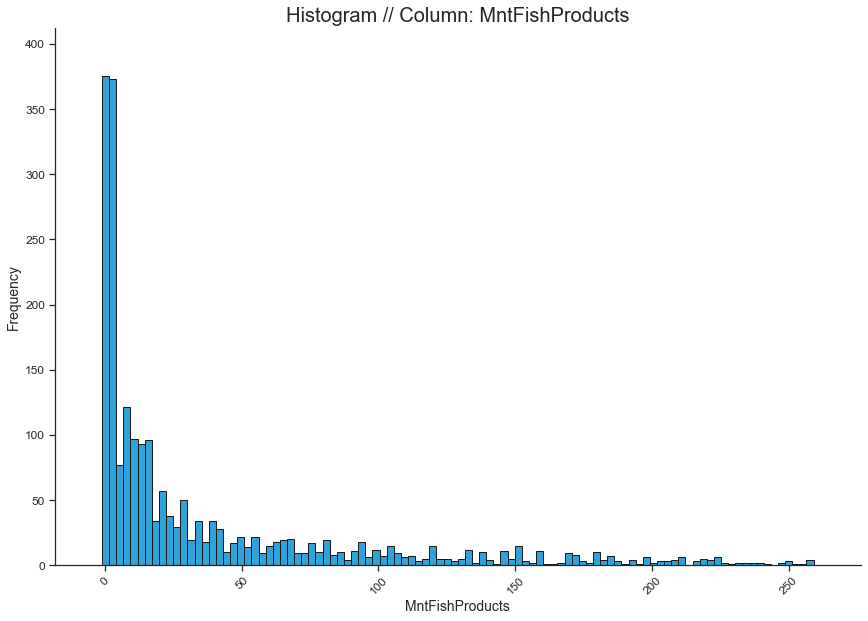

In [62]:
numerical_histogram(df_camp, 'MntFishProducts', bins=100, height=800)


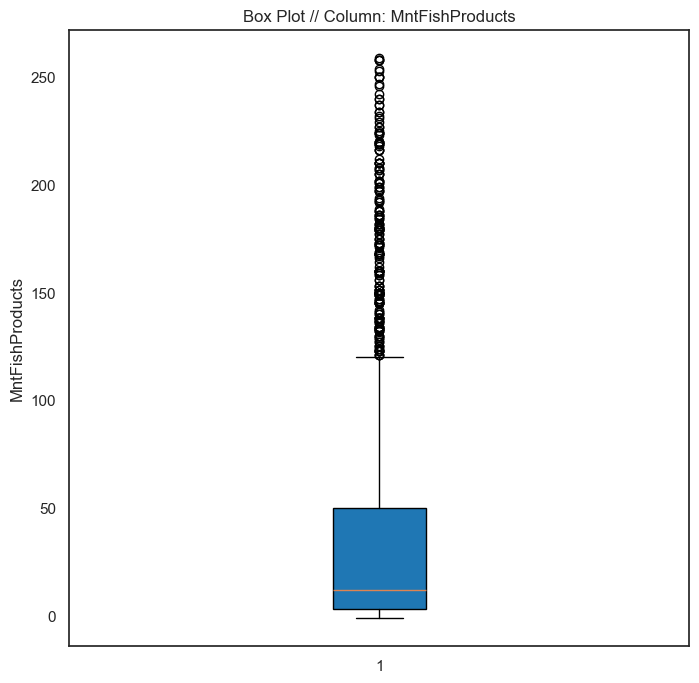

In [63]:
numerical_boxplot(df_camp, 'MntFishProducts', height=800, width=800)


`MntSweetProducts` | Numerical


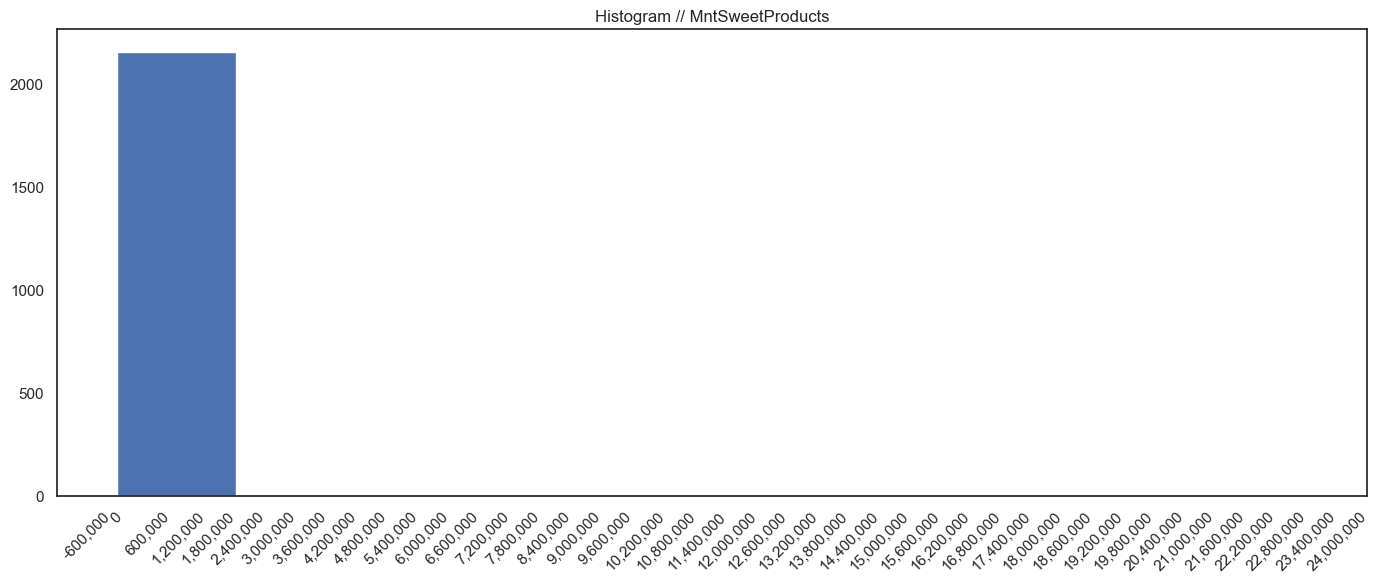

In [65]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator

# 1) your integer‑with‑commas formatter
plain_int = FuncFormatter(lambda x, pos: f"{int(x):,}")

fig, ax = plt.subplots(figsize=(14,6))
ax.hist(df_camp['MntSweetProducts'].dropna(), bins=10)
ax.set_title("Histogram // MntSweetProducts")

# 2) disable scientific notation & offset…
ax.ticklabel_format(style='plain', axis='x')
ax.xaxis.set_major_locator(MaxNLocator(nbins=50, integer=True, prune=None))
# 3) …then put your comma‑formatter in
ax.xaxis.set_major_formatter(plain_int)
ax.tick_params(axis='x', rotation=45)

# 4) and hide that little offset text
ax.xaxis.get_offset_text().set_visible(False)

plt.tight_layout()
plt.show()


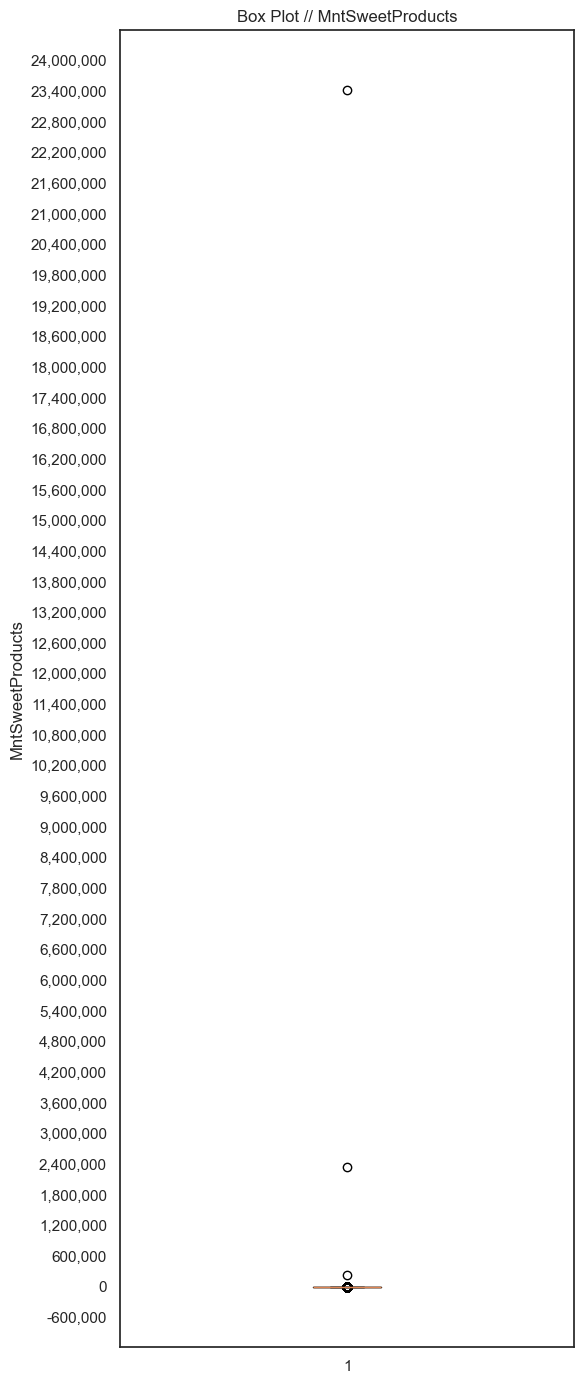

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MaxNLocator

# your comma formatter
plain_int = FuncFormatter(lambda x, pos: f"{int(x):,}")

fig, ax = plt.subplots(figsize=(6,14))
ax.boxplot(df_camp['MntSweetProducts'].dropna(), vert=True)
ax.set_title("Box Plot // MntSweetProducts")
ax.set_ylabel("MntSweetProducts")

# turn off sci‑notation & offset
ax.yaxis.set_major_formatter(plain_int)

# *** HERE: force ~6 ticks on the y‑axis ***
ax.yaxis.set_major_locator(MaxNLocator(nbins=50, integer=True, prune=None))

plt.tight_layout()
plt.show()


`MntGoldProds`| Numerical


:Histogram   [MntGoldProds]   (MntGoldProds_count)
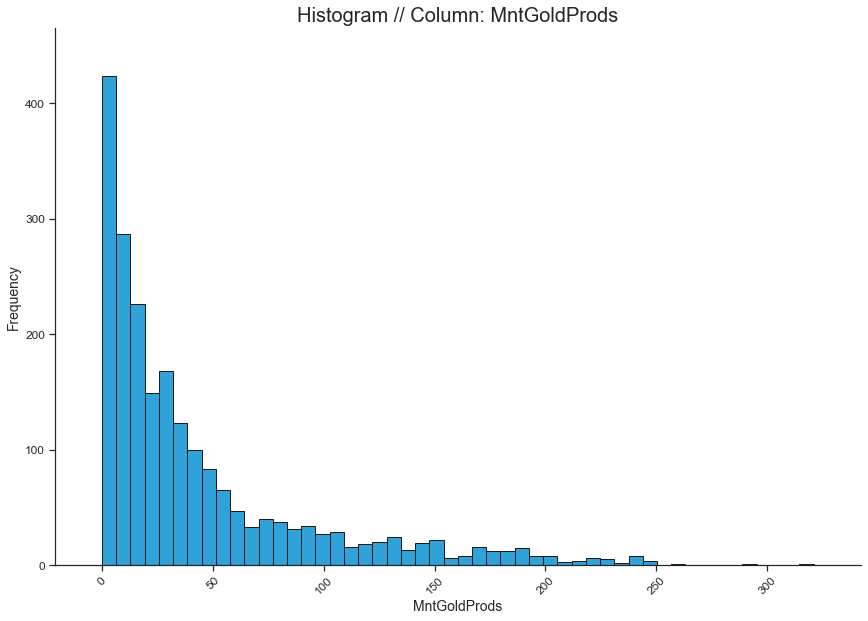

In [68]:
numerical_histogram(df_camp, 'MntGoldProds', bins=50, height=800)


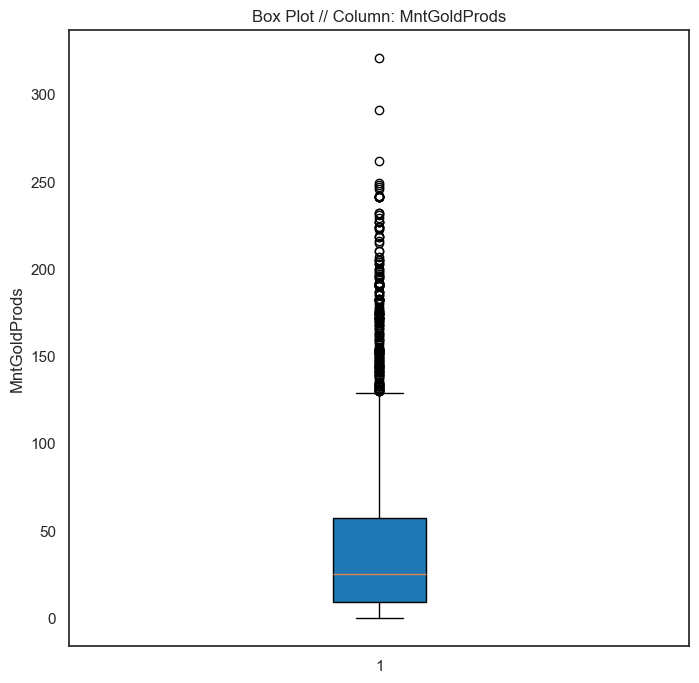

In [69]:
numerical_boxplot(df_camp, 'MntGoldProds', height=800, width=800)


`NumDealsPurchases` | Numerical


:Histogram   [NumDealsPurchases]   (NumDealsPurchases_count)
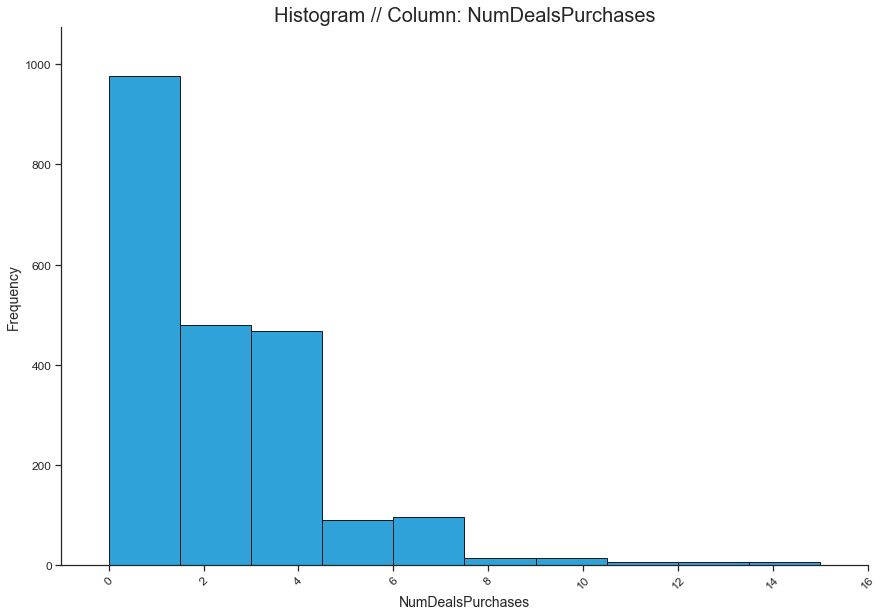

In [71]:
numerical_histogram(df_camp, 'NumDealsPurchases', bins=10, height=800)


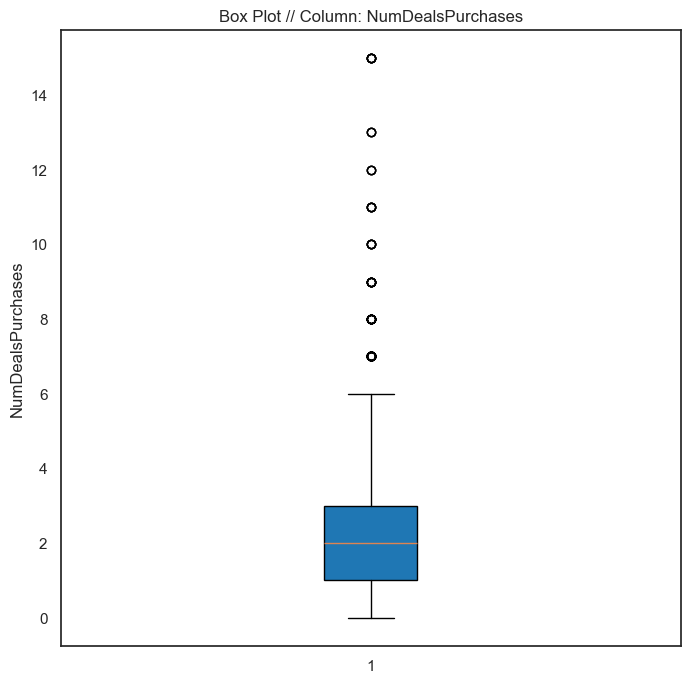

In [72]:
numerical_boxplot(df_camp, 'NumDealsPurchases', height=800, width=800)


`NumWebPurchases` | Numerical


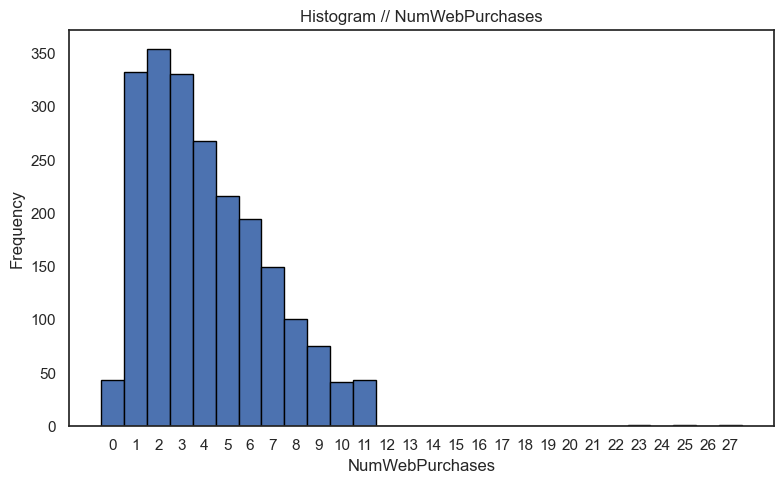

In [74]:
import numpy as np
import matplotlib.pyplot as plt

# 1) compute integer bins that run from −0.5→0.5, 0.5→1.5, … so that
#    the *centers* end up exactly at 0,1,2,…
max_web = df_camp['NumWebPurchases'].max()
bins = np.arange(-0.5, max_web + 1.5, 1)   # edges: -0.5, 0.5, 1.5, …, max+0.5

fig, ax = plt.subplots(figsize=(8,5))
ax.hist(df_camp['NumWebPurchases'].dropna(), bins=bins, edgecolor='black')

# 2) now set your ticks at the integer centers
ax.set_xticks(np.arange(0, max_web+1, 1))
ax.set_xticklabels(np.arange(0, max_web+1, 1))

ax.set_xlabel('NumWebPurchases')
ax.set_ylabel('Frequency')
ax.set_title('Histogram // NumWebPurchases')
plt.tight_layout()
plt.show()


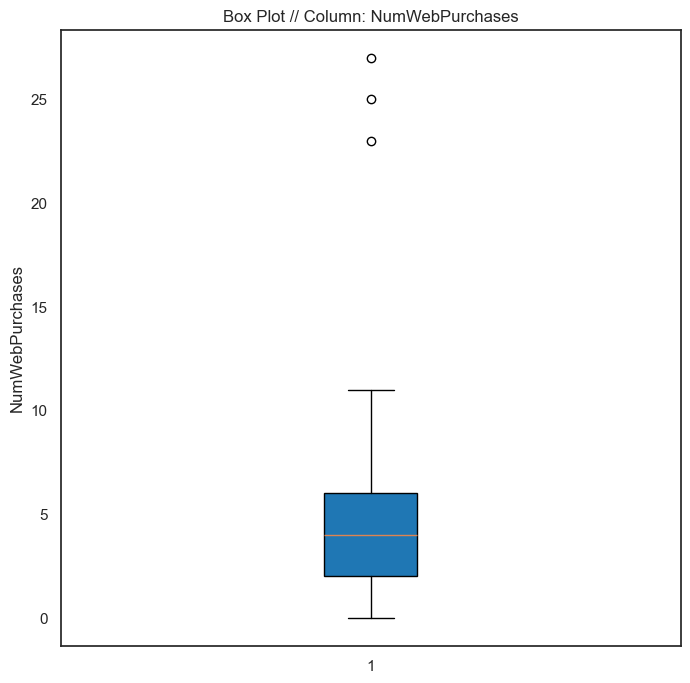

In [75]:
numerical_boxplot(df_camp, 'NumWebPurchases', height=800, width=800)


`NumCatalogPurchases` | Numerical


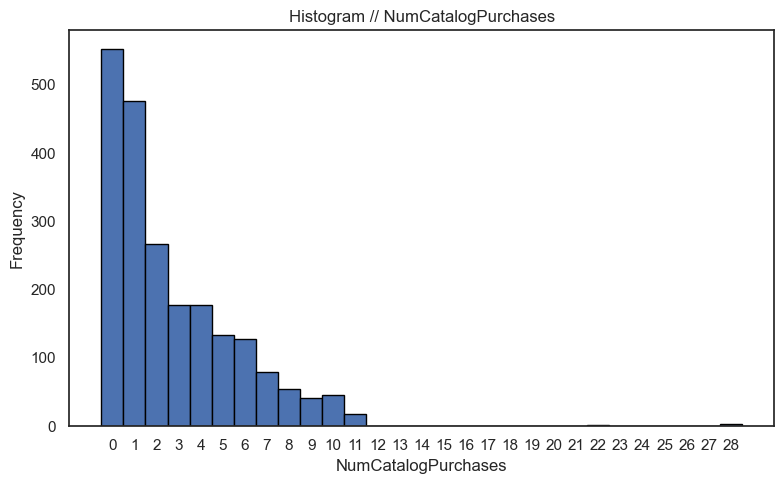

In [77]:
import numpy as np
import matplotlib.pyplot as plt

# 1) compute integer bins that run from −0.5→0.5, 0.5→1.5, … so that
#    the *centers* end up exactly at 0,1,2,…
max_web = df_camp['NumCatalogPurchases'].max()
bins = np.arange(-0.5, max_web + 1.5, 1)   # edges: -0.5, 0.5, 1.5, …, max+0.5

fig, ax = plt.subplots(figsize=(8,5))
ax.hist(df_camp['NumCatalogPurchases'].dropna(), bins=bins, edgecolor='black')

# 2) now set your ticks at the integer centers
ax.set_xticks(np.arange(0, max_web+1, 1))
ax.set_xticklabels(np.arange(0, max_web+1, 1))

ax.set_xlabel('NumCatalogPurchases')
ax.set_ylabel('Frequency')
ax.set_title('Histogram // NumCatalogPurchases')
plt.tight_layout()
plt.show()


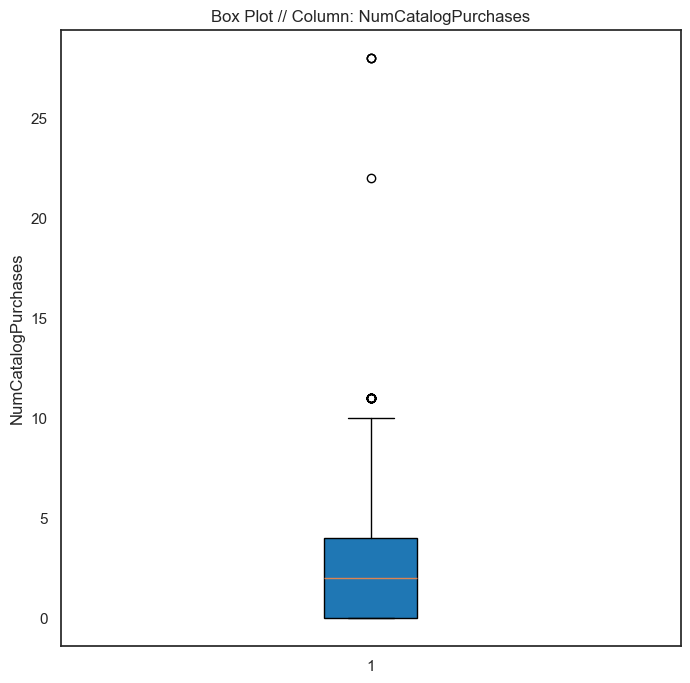

In [78]:
numerical_boxplot(df_camp, 'NumCatalogPurchases', height=800, width=800)


`NumStorePurchases` | Numerical


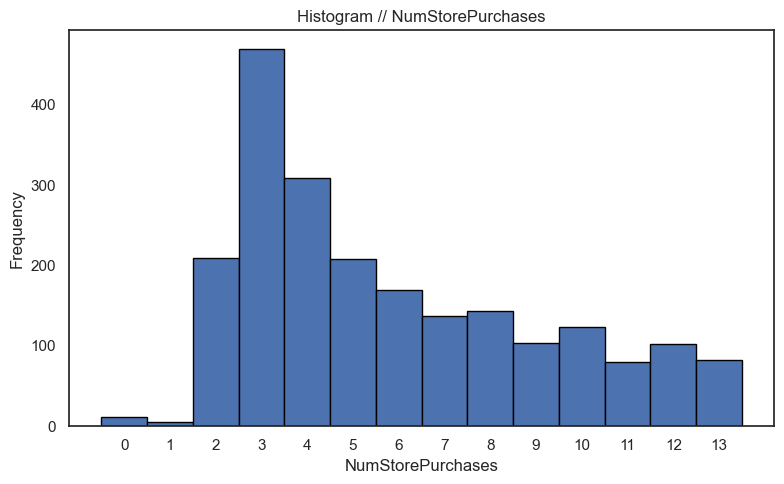

In [80]:
import numpy as np
import matplotlib.pyplot as plt

# 1) compute integer bins that run from −0.5→0.5, 0.5→1.5, … so that
#    the *centers* end up exactly at 0,1,2,…
max_web = df_camp['NumStorePurchases'].max()
bins = np.arange(-0.5, max_web + 1.5, 1)   # edges: -0.5, 0.5, 1.5, …, max+0.5

fig, ax = plt.subplots(figsize=(8,5))
ax.hist(df_camp['NumStorePurchases'].dropna(), bins=bins, edgecolor='black')

# 2) now set your ticks at the integer centers
ax.set_xticks(np.arange(0, max_web+1, 1))
ax.set_xticklabels(np.arange(0, max_web+1, 1))

ax.set_xlabel('NumStorePurchases')
ax.set_ylabel('Frequency')
ax.set_title('Histogram // NumStorePurchases')
plt.tight_layout()
plt.show()


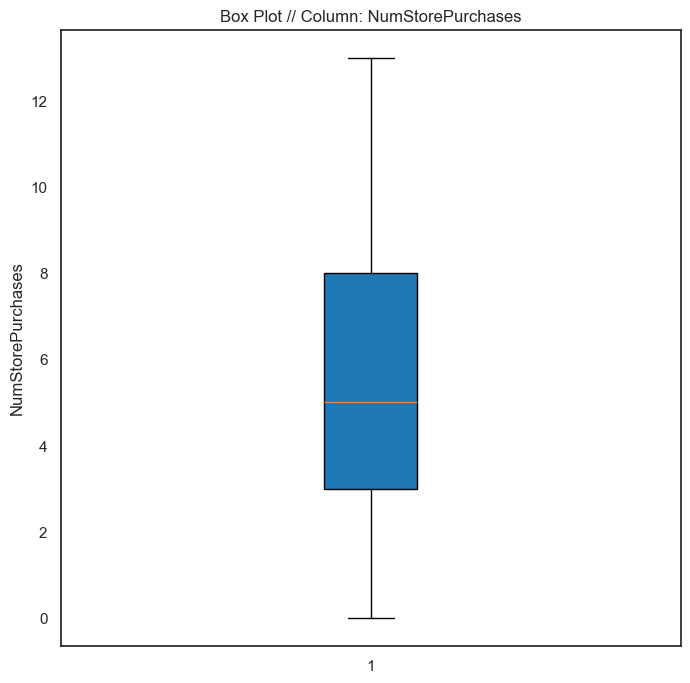

In [81]:
numerical_boxplot(df_camp, 'NumStorePurchases', height=800, width=800)


`NumWebVisitsMonth` | Numerical


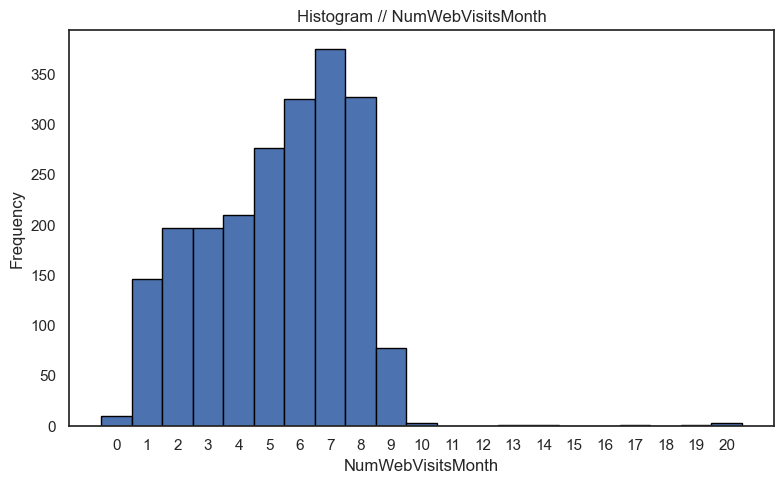

In [83]:
import numpy as np
import matplotlib.pyplot as plt

# 1) compute integer bins that run from −0.5→0.5, 0.5→1.5, … so that
#    the *centers* end up exactly at 0,1,2,…
max_web = df_camp['NumWebVisitsMonth'].max()
bins = np.arange(-0.5, max_web + 1.5, 1)   # edges: -0.5, 0.5, 1.5, …, max+0.5

fig, ax = plt.subplots(figsize=(8,5))
ax.hist(df_camp['NumWebVisitsMonth'].dropna(), bins=bins, edgecolor='black')

# 2) now set your ticks at the integer centers
ax.set_xticks(np.arange(0, max_web+1, 1))
ax.set_xticklabels(np.arange(0, max_web+1, 1))

ax.set_xlabel('NumWebVisitsMonth')
ax.set_ylabel('Frequency')
ax.set_title('Histogram // NumWebVisitsMonth')
plt.tight_layout()
plt.show()


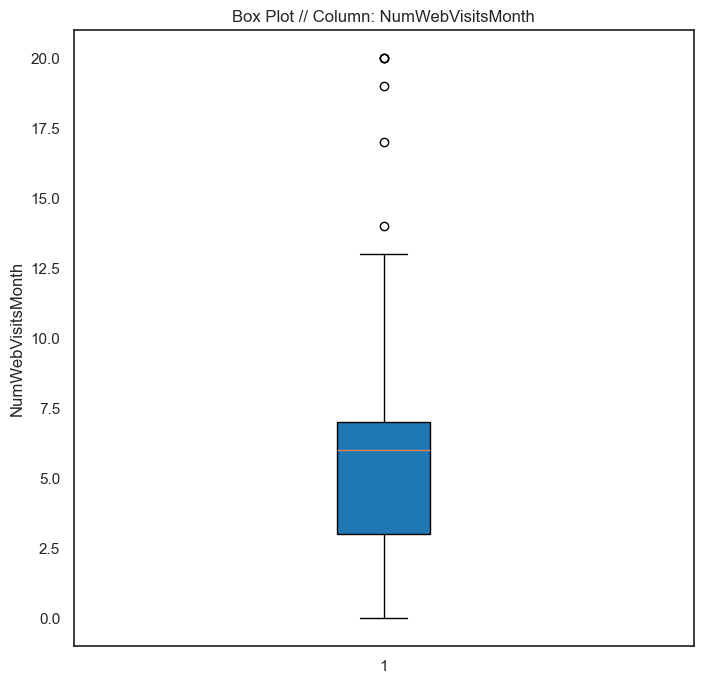

In [84]:
numerical_boxplot(df_camp, 'NumWebVisitsMonth', height=800, width=800)


In [85]:
df_camp['NumWebVisitsMonth'].value_counts()


NumWebVisitsMonth
7     375
8     328
6     326
5     277
4     210
2     197
3     197
1     146
9      78
0      10
20      3
10      3
17      1
14      1
19      1
13      1
Name: count, dtype: int64

`AcceptedCmp3` | Boolean


:Bars   [AcceptedCmp3]   (count)
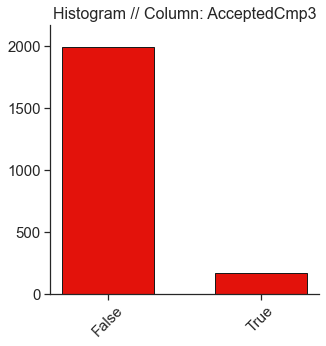

In [87]:
categorical_histogram(df_camp, 'AcceptedCmp3', height=400, width=400)


`AcceptedCmp4` | Boolean


:Bars   [AcceptedCmp4]   (count)
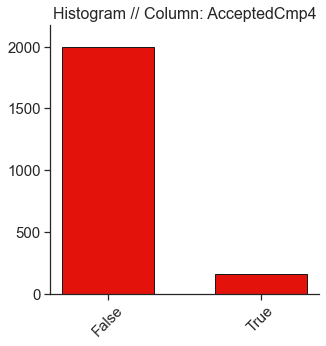

In [89]:
categorical_histogram(df_camp, 'AcceptedCmp4', height=400, width=400)


`AcceptedCmp5` | Boolean


:Bars   [AcceptedCmp5]   (count)
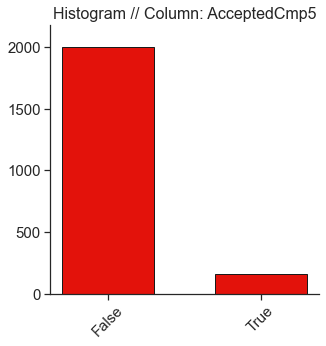

In [91]:
categorical_histogram(df_camp, 'AcceptedCmp5', height=400, width=400)


`AcceptedCmp1` | Boolean


:Bars   [AcceptedCmp1]   (count)
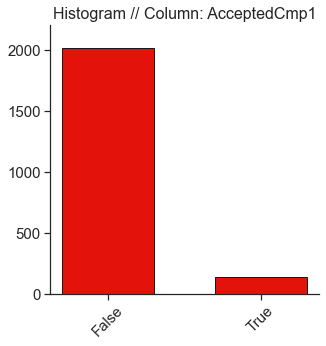

In [93]:
categorical_histogram(df_camp, 'AcceptedCmp1', height=400, width=400)


`AcceptedCmp2` | Boolean


:Bars   [AcceptedCmp2]   (count)
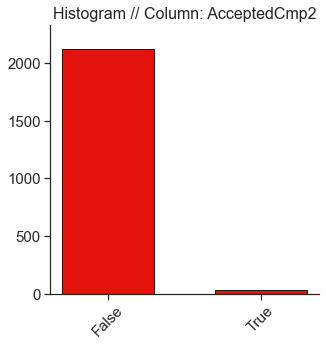

In [95]:
categorical_histogram(df_camp, 'AcceptedCmp2', height=400, width=400)


`Complain` | Boolean


:Bars   [Complain]   (count)
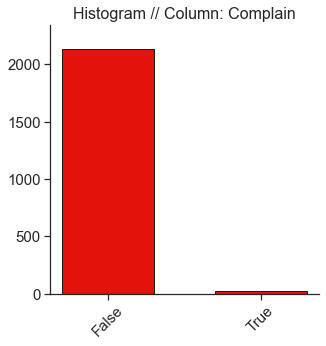

In [97]:
categorical_histogram(df_camp, 'Complain', height=400, width=400)


`Response` | Boolean


:Bars   [Response]   (count)
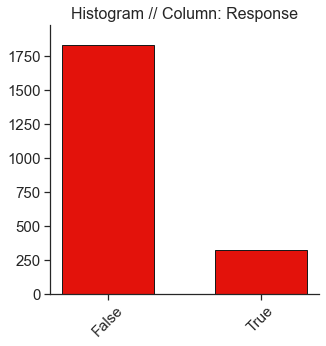

In [99]:
categorical_histogram(df_camp, 'Response', height=400, width=400)


`Z_CostContact` | Dataset metadata field not documented in the available description


`Z_Revenue` | Dataset metadata field not documented in the available description


## 0.3 EDA: Multivariate Analysis


In [103]:
numerical_var = (
    'Recency',
    'MntWines', 
    'MntFruits', 
    'MntMeatProducts', 
    'MntFishProducts', 
    'MntSweetProducts', 
    'MntGoldProds', 
    'NumDealsPurchases', 
    'NumWebPurchases', 
    'NumCatalogPurchases', 
    'NumStorePurchases', 
    'NumWebVisitsMonth', 
    'Income'
)


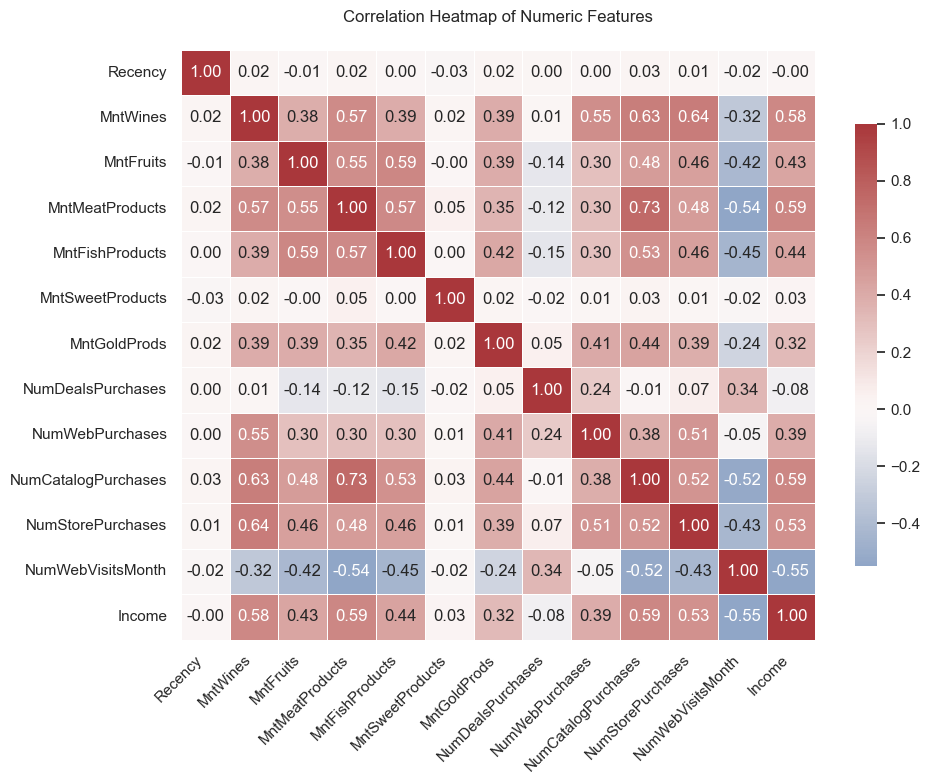

In [104]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1) compute the corr matrix
cols = list(numerical_var)
corr = df_camp[cols].corr()

# 2) plot
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    annot=True,        # show the correlation coefficients
    fmt=".2f",         # 2 decimal places
    cmap="vlag",       # blue ↔ red diverging
    center=0,          # white at zero
    linewidths=0.5,    # grid lines between cells
    cbar_kws={"shrink": .75}  # colorbar size
)
plt.title("Correlation Heatmap of Numeric Features", pad=20)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


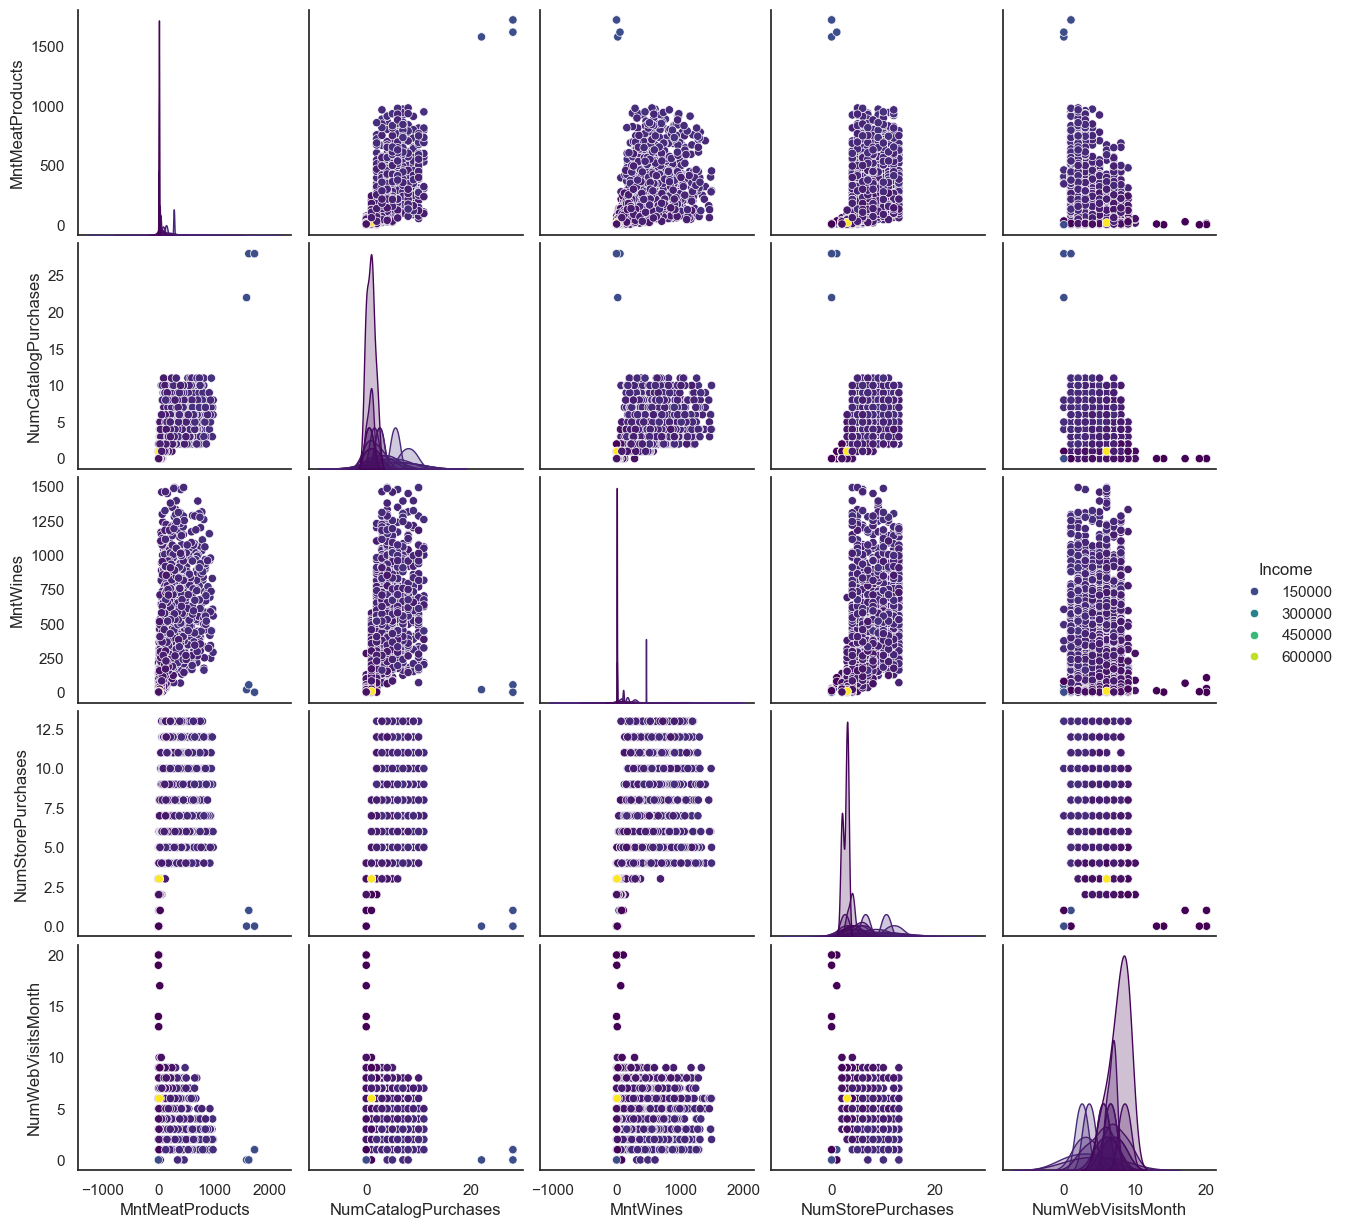

In [105]:
vars = [
    "MntMeatProducts","NumCatalogPurchases",
    "MntWines",      "NumStorePurchases",
    "Income",        "NumWebVisitsMonth"
]
sns.pairplot(df_camp[vars], corner=False, height=2.5, hue='Income', palette='viridis')


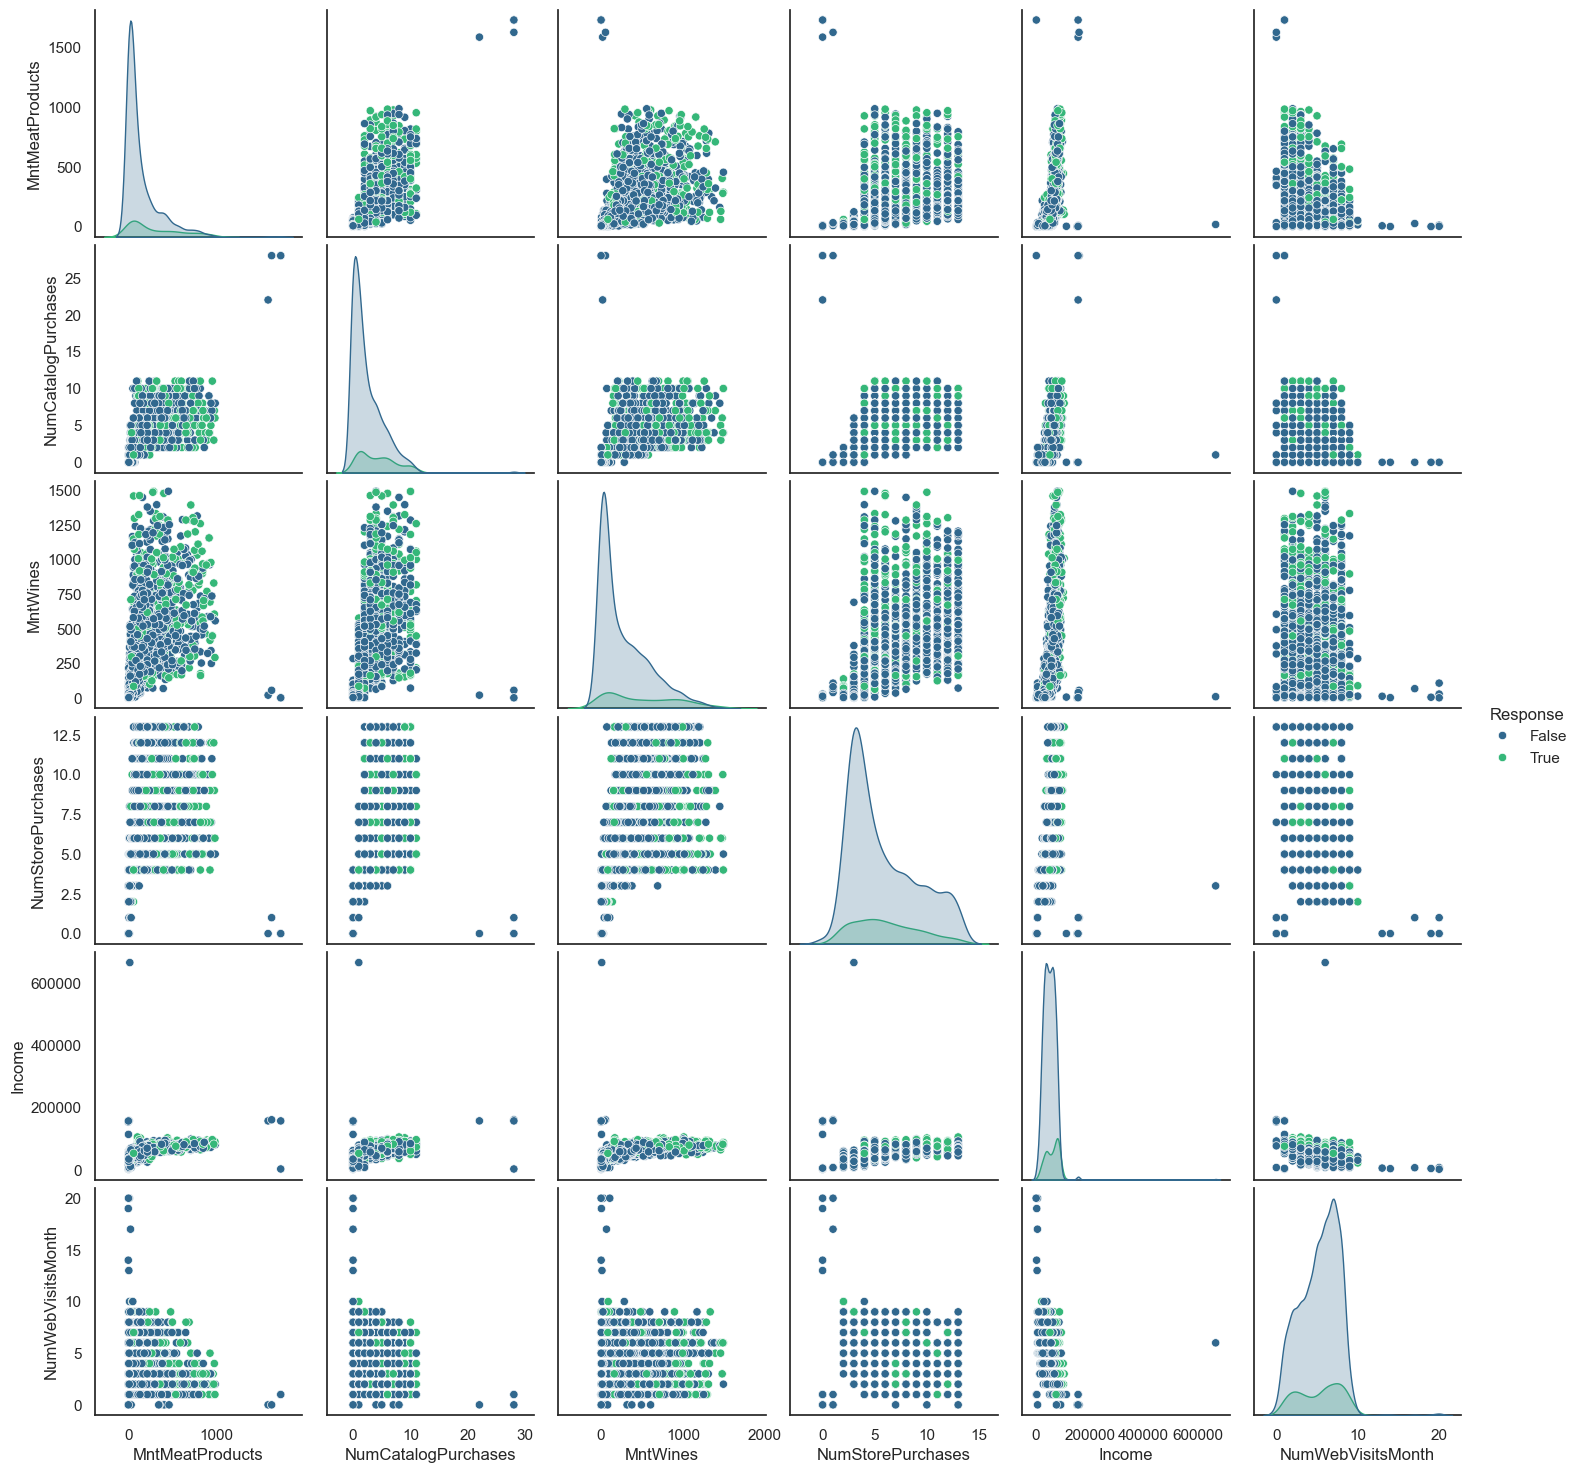

In [106]:
vars = [
    "MntMeatProducts","NumCatalogPurchases",
    "MntWines",      "NumStorePurchases",
    "Income",        "NumWebVisitsMonth",
    "Response"
]
sns.pairplot(df_camp[vars], corner=False, height=2.5, hue='Response', palette='viridis')


Here we can see outliers that appear when we combine numerical and analyze them based on response.


In [108]:
cat_cols = (
    'Year_Birth',
    'Education',
    'Marital_Status',
    'Kidhome',
    'Teenhome',
    'AcceptedCmp3', 
    'AcceptedCmp4',
    'AcceptedCmp5',
    'AcceptedCmp1',
    'AcceptedCmp2',
    'Complain',
    'Response'
)


In [109]:
card = df_camp.loc[:, cat_cols].nunique().sort_values()
print(card)


AcceptedCmp3       2
AcceptedCmp4       2
AcceptedCmp5       2
AcceptedCmp1       2
AcceptedCmp2       2
Complain           2
Response           2
Kidhome            3
Teenhome           3
Education          5
Marital_Status     5
Year_Birth        59
dtype: int64


In [110]:
import numpy as np, pandas as pd, scipy.stats as ss

def cramers_v(x, y):
    cm = pd.crosstab(x, y)
    chi2 = ss.chi2_contingency(cm)[0]
    n = cm.sum().sum()
    phi2 = chi2 / n
    r, k = cm.shape
    return np.sqrt(phi2 / min(k-1, r-1))

# build the pairwise Cramer’s V matrix
vars_ = cat_cols
cr = pd.DataFrame(index=vars_, columns=vars_, dtype=float)
for a in vars_:
    for b in vars_:
        cr.loc[a,b] = cramers_v(df_camp[a], df_camp[b])


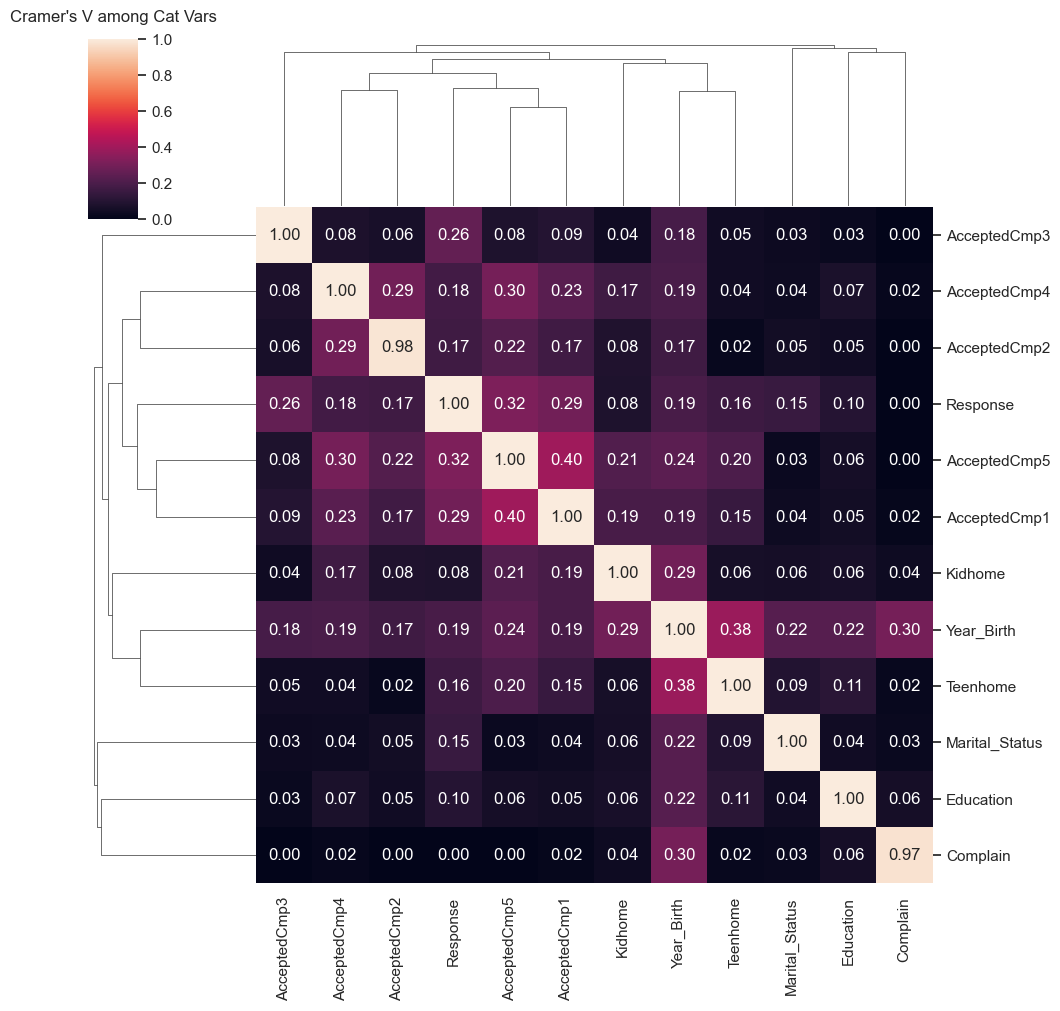

In [111]:
import seaborn as sns, matplotlib.pyplot as plt
sns.clustermap(cr.astype(float), annot=True, fmt=".2f", cmap="rocket")
plt.title("Cramer's V among Cat Vars", y=1.05)
plt.show()


In [112]:
groups = {
  "Demographics": ['Education','Marital_Status','Income'],
  "Engagement": ['NumWebVisitsMonth','NumDealsPurchases'],
  "Channel": ['NumWebPurchases','NumCatalogPurchases','NumStorePurchases']
}


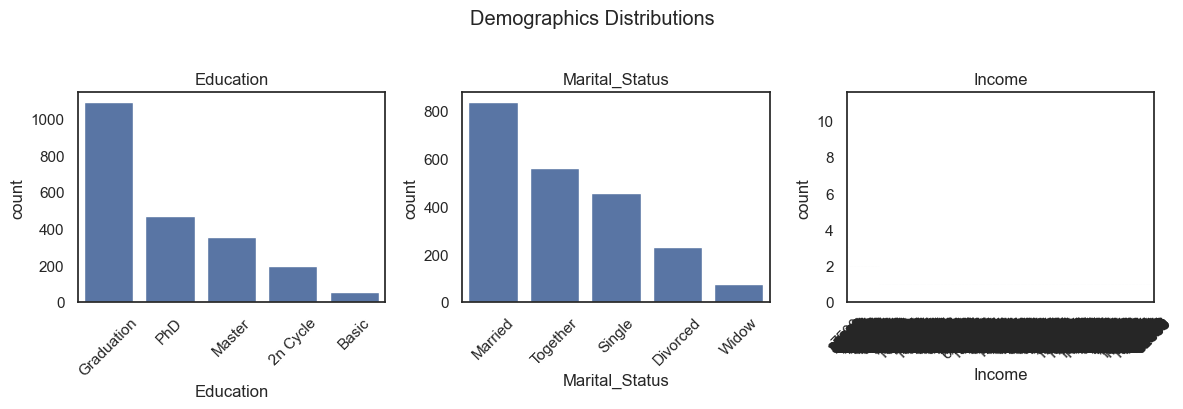

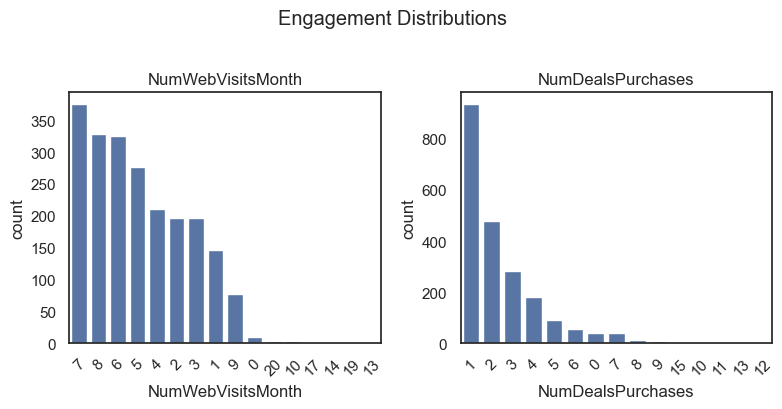

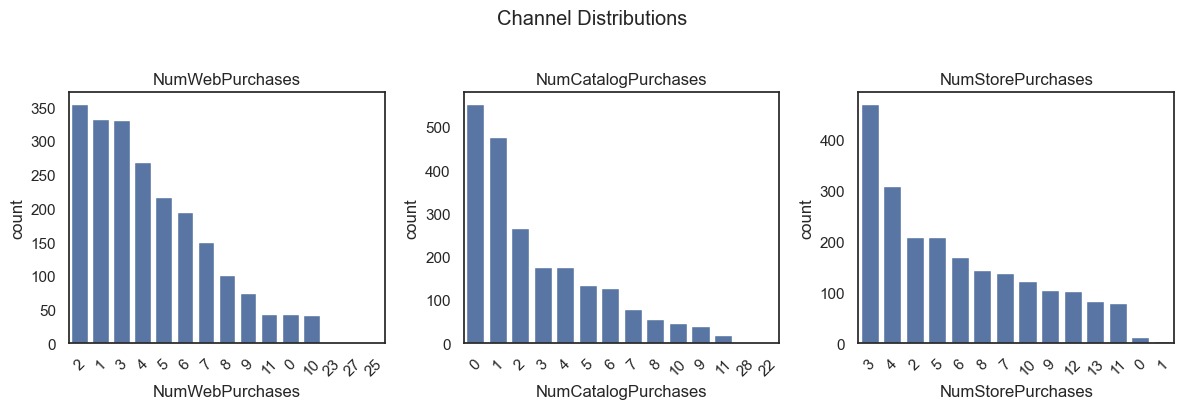

In [113]:
for title, cols in groups.items():
    fig, axes = plt.subplots(1, len(cols), figsize=(4*len(cols),4))
    for ax, col in zip(axes, cols):
        sns.countplot(data=df_camp, x=col, ax=ax,
                      order=df_camp[col].value_counts().index)
        ax.set_title(col)
        ax.tick_params(axis='x', rotation=45)
    fig.suptitle(f"{title} Distributions", y=1.02)
    plt.tight_layout()
    plt.show()


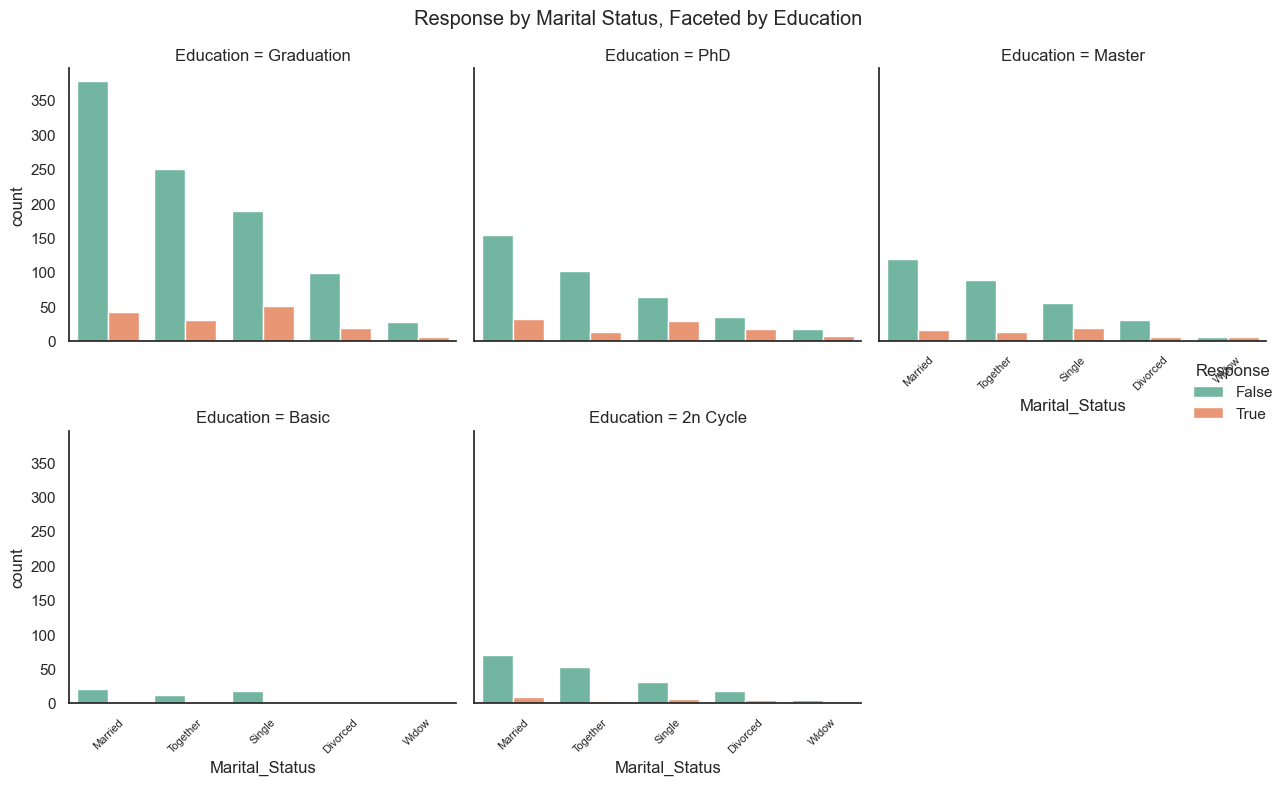

In [114]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.catplot(
    data=df_camp,
    x='Marital_Status',
    hue='Response',
    col='Education',
    kind='count',
    col_wrap=3,
    height=4,
    palette="Set2",
    order=df_camp['Marital_Status'].value_counts().index  # optional: fix order
)

# rotate all the x‑labels on every facet
for ax in g.axes.flatten():
    ax.tick_params(axis='x', rotation=45, labelsize=8)

plt.subplots_adjust(top=0.9)
g.fig.suptitle("Response by Marital Status, Faceted by Education")
plt.tight_layout()
plt.show()


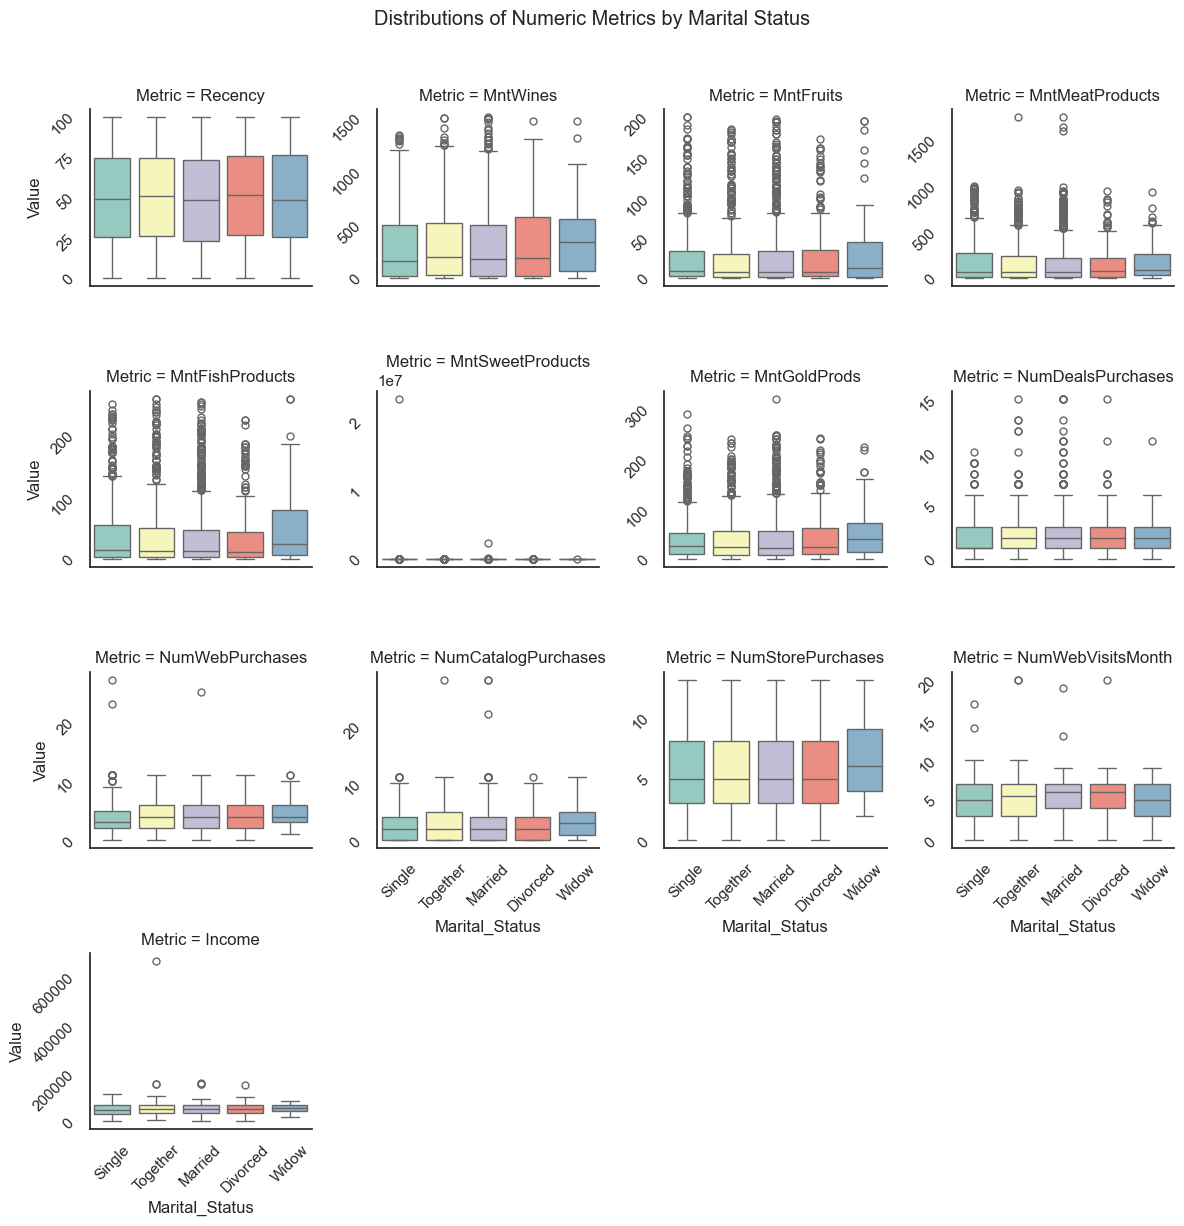

In [115]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# pick the categorical you care about:
cat = 'Marital_Status'

# 1) long form: id_vars = your cat, value_vars = all the numerics
df_long = df_camp.melt(
    id_vars=[cat], 
    value_vars=numerical_var, 
    var_name='Metric', 
    value_name='Value'
)

# 2) one FacetGrid of boxplots, one facet per Metric
g = sns.catplot(
    data=df_long,
    x=cat,
    y='Value',
    col='Metric',
    col_wrap=4,        # 4 plots per row
    sharey=False,      # each facet its own y‑scale
    kind='box',
    height=3,
    aspect=1,
    palette="Set3",
    hue='Marital_Status'
)

# rotate x‑labels for readability
for ax in g.axes.flatten():
    ax.tick_params(labelrotation=45)

g.fig.suptitle("Distributions of Numeric Metrics by Marital Status", y=1.02)
plt.tight_layout()
plt.show()


In [ ]:
#export clean dataset
df_camp_clean = df_camp.to_csv('data/campaign_clean.csv', index=False)
